# Global Weather Repository  Trend Forecasting & Advanced Analysis

---

## PM Accelerator Mission

> **PM Accelerator** is the world's leading Product Manager training program.
> Our mission is to accelerate the careers of aspiring and experienced Product Managers
> through real-world projects, mentorship, and a global community.
> We believe everyone deserves access to world-class PM education  regardless of background.
> Visit us at [pmaccelerator.io](https://www.pmaccelerator.io)

---

### About this notebook
End-to-end analysis of the Global Weather Repository dataset  daily weather for capital cities worldwide, starting May 2024.
Covers data cleaning, EDA, anomaly detection, multi-model forecasting with an ensemble, climate analysis, air quality impact, feature importance, and spatial visualization.

**Sections:**
1. Setup & imports
2. Data loading & cleaning
3. Exploratory data analysis
4. Anomaly detection
5. Time series forecasting  multiple models + ensemble
6. Climate pattern analysis
7. Air quality & environmental impact
8. Feature importance (shap)
9. Spatial & geographical analysis
10. Summary & insights


## 1. Setup & imports

Pull in everything we need. Prophet and shap are optional  the notebook handles missing installs gracefully so nothing breaks if they're not present.

In [54]:
# [note] uncomment the line below first time you run this
# !pip install prophet shap plotly scikit-learn xgboost lightgbm statsmodels folium

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import xgboost as xgb
import lightgbm as lgb

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose

try:
    from prophet import Prophet
    PROPHET_AVAILABLE = True
except ImportError:
    PROPHET_AVAILABLE = False
    print("prophet not found, skipping that model  pip install prophet to enable")

try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print("shap not found  pip install shap to enable feature explanation plots")

try:
    import folium
    from folium.plugins import HeatMap
    FOLIUM_AVAILABLE = True
except ImportError:
    FOLIUM_AVAILABLE = False
    print("folium not found  pip install folium for the interactive map")

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (12, 5)})

print("imports done")


imports done


## 2. Data loading & cleaning

Load the raw csv and take a first look at shape, column names and dtypes before touching anything.

In [55]:
df = pd.read_csv('GlobalWeatherRepository.csv')
print(f"raw shape: {df.shape}")
df.head(3)


raw shape: (144042, 41)


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55


Quick summary of column types and non-null counts. Helps us spot which columns are mostly empty before we decide how to handle them.

In [56]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 144042 entries, 0 to 144041
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   country                       144042 non-null  str    
 1   location_name                 144042 non-null  str    
 2   latitude                      144042 non-null  float64
 3   longitude                     144042 non-null  float64
 4   timezone                      144042 non-null  str    
 5   last_updated_epoch            144042 non-null  int64  
 6   last_updated                  144042 non-null  str    
 7   temperature_celsius           144042 non-null  float64
 8   temperature_fahrenheit        144042 non-null  float64
 9   condition_text                144042 non-null  str    
 10  wind_mph                      144042 non-null  float64
 11  wind_kph                      144042 non-null  float64
 12  wind_degree                   144042 non-null  int64  


Count and visualise missing values per column. Air quality features tend to be sparsest, so we'll treat them separately from the core weather columns.

In [57]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'count': missing, 'pct': missing_pct})
missing_df = missing_df[missing_df['count'] > 0].sort_values('pct', ascending=False)
print(missing_df)

if not missing_df.empty:
    fig, ax = plt.subplots(figsize=(10, max(4, len(missing_df) * 0.4)))
    missing_df['pct'].plot(kind='barh', ax=ax, color='salmon')
    ax.set_xlabel('missing %')
    ax.set_title('missing values by column')
    plt.tight_layout()
    plt.show()
else:
    print("no missing values  clean dataset")


Empty DataFrame
Columns: [count, pct]
Index: []
no missing values  clean dataset


Parse the `last_updated` column to datetime and extract time components we'll need later for seasonality features and time series grouping.

In [58]:
# [fix] last_updated comes in as a string with local timezone offsets, coerce handles any bad rows
df['last_updated'] = pd.to_datetime(df['last_updated'], errors='coerce')
df['date'] = pd.to_datetime(df['last_updated'].dt.date)
df['year'] = df['last_updated'].dt.year
df['month'] = df['last_updated'].dt.month
df['day_of_year'] = df['last_updated'].dt.dayofyear

print("date range:", df['last_updated'].min(), "->", df['last_updated'].max())
print("unique countries:", df['country'].nunique())
print("unique cities:", df['location_name'].nunique())


date range: 2024-05-16 01:45:00 -> 2026-05-28 19:15:00
unique countries: 211
unique cities: 257


Drop exact duplicate rows and remove the redundant unit columns  we keep only SI units to avoid multicollinearity in models downstream.

In [59]:
before = len(df)
df.drop_duplicates(inplace=True)
print(f"duplicates removed: {before - len(df)}")

# [note] keeping celsius, kph, mb, mm  dropping the imperial twins and the epoch column
# since last_updated already gives us datetime
redundant = [
    'temperature_fahrenheit', 'wind_mph', 'pressure_in',
    'precip_in', 'feels_like_fahrenheit', 'visibility_miles',
    'gust_mph', 'last_updated_epoch'
]
df.drop(columns=[c for c in redundant if c in df.columns], inplace=True)
print(f"columns after cleanup: {df.shape[1]}")


duplicates removed: 0
columns after cleanup: 37


Fill missing values. Air quality columns get median-imputed globally since they can be sparse. Other numeric columns are forward-filled per city (preserving local trends) then backfilled to catch leading NaNs.

In [60]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
aq_cols = [c for c in numeric_cols if 'air_quality' in c]

# [feature] group-aware imputation keeps each city's own trend rather than pulling toward global mean
for col in aq_cols:
    df[col].fillna(df[col].median(), inplace=True)

df.sort_values(['location_name', 'last_updated'], inplace=True)
df[numeric_cols] = df.groupby('location_name')[numeric_cols].transform(
    lambda x: x.ffill().bfill()
)

for col in numeric_cols:
    if df[col].isnull().any():
        df[col].fillna(df[col].median(), inplace=True)

print("missing after imputation:", df.isnull().sum().sum())


missing after imputation: 0


Detect and cap outliers using the 1st/99th percentile IQR method. This is softer than dropping rows  we preserve the record but clip extreme values that are likely sensor errors.

In [62]:
core_numeric = ['temperature_celsius', 'humidity', 'precip_mm',
                'wind_kph', 'pressure_mb', 'visibility_km', 'uv_index']
core_numeric = [c for c in core_numeric if c in df.columns]

outlier_report = {}
for col in core_numeric:
    Q1 = df[col].quantile(0.01)
    Q3 = df[col].quantile(0.99)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n = ((df[col] < lo) | (df[col] > hi)).sum()
    outlier_report[col] = n
    df[col] = df[col].clip(lo, hi)

print("outliers capped per column:")
for k, v in outlier_report.items():
    print(f"  {k}: {v} rows")

print(f"final shape: {df.shape}")


outliers capped per column:
  temperature_celsius: 0 rows
  humidity: 0 rows
  precip_mm: 192 rows
  wind_kph: 6 rows
  pressure_mb: 2 rows
  visibility_km: 0 rows
  uv_index: 0 rows
final shape: (144042, 37)


Map each country to a continent so we can do region-level comparisons in EDA and spatial sections.

In [63]:
continent_map = {
    'Africa': ['Algeria','Angola','Benin','Botswana','Burkina Faso','Burundi',
               'Cameroon','Cape Verde','Central African Republic','Chad','Comoros',
               'Congo','Democratic Republic of Congo','Djibouti','Egypt',
               'Equatorial Guinea','Eritrea','Ethiopia','Gabon','Gambia','Ghana',
               'Guinea','Guinea-Bissau','Ivory Coast','Kenya','Lesotho','Liberia',
               'Libya','Madagascar','Malawi','Mali','Mauritania','Mauritius',
               'Morocco','Mozambique','Namibia','Niger','Nigeria','Rwanda',
               'Sao Tome and Principe','Senegal','Seychelles','Sierra Leone',
               'Somalia','South Africa','South Sudan','Sudan','Swaziland',
               'Tanzania','Togo','Tunisia','Uganda','Zambia','Zimbabwe'],
    'Asia': ['Afghanistan','Armenia','Azerbaijan','Bahrain','Bangladesh','Bhutan',
             'Brunei Darussalam','Cambodia','China','Cyprus','Georgia','India',
             'Indonesia','Iran','Iraq','Israel','Japan','Jordan','Kazakhstan',
             'Kuwait','Kyrghyzstan','Laos','Lebanon','Malaysia','Maldives',
             'Mongolia','Myanmar','Nepal','North Korea','Oman','Pakistan',
             'Philippines','Qatar','Saudi Arabia','Singapore','South Korea',
             'Sri Lanka','Syria','Taiwan','Tajikistan','Thailand','Timor-Leste',
             'Turkey','Turkmenistan','United Arab Emirates','Uzbekistan','Vietnam','Yemen'],
    'Europe': ['Albania','Andorra','Austria','Belarus','Belgium',
               'Bosnia and Herzegovina','Bulgaria','Croatia','Czech Republic',
               'Denmark','Estonia','Finland','France','Germany','Greece',
               'Hungary','Iceland','Ireland','Italy','Latvia','Liechtenstein',
               'Lithuania','Luxembourg','Malta','Moldova','Monaco','Montenegro',
               'Netherlands','North Macedonia','Norway','Poland','Portugal',
               'Romania','Russia','San Marino','Serbia','Slovakia','Slovenia',
               'Spain','Sweden','Switzerland','Ukraine','United Kingdom','Vatican City'],
    'North America': ['Antigua and Barbuda','Bahamas','Barbados','Belize','Canada',
                      'Costa Rica','Cuba','Dominica','Dominican Republic',
                      'El Salvador','Grenada','Guatemala','Haiti','Honduras',
                      'Jamaica','Mexico','Nicaragua','Panama',
                      'Saint Kitts and Nevis','Saint Lucia',
                      'Saint Vincent and the Grenadines','Trinidad and Tobago',
                      'United States'],
    'South America': ['Argentina','Bolivia','Brazil','Chile','Colombia','Ecuador',
                      'Guyana','Paraguay','Peru','Suriname','Uruguay','Venezuela'],
    'Oceania': ['Australia','Fiji Islands','Kiribati','Marshall Islands',
                'Micronesia','Nauru','New Zealand','Palau','Papua New Guinea',
                'Samoa','Solomon Islands','Tonga','Tuvalu','Vanuatu'],
}
country_to_continent = {c: k for k, v in continent_map.items() for c in v}
df['continent'] = df['country'].map(country_to_continent).fillna('Other')
print(df['continent'].value_counts())


continent
Asia             37369
Africa           36681
Europe           32845
North America    16191
Oceania           9608
South America     8840
Other             2508
Name: count, dtype: int64


## 3. Exploratory data analysis

Descriptive statistics for the core numeric features  a sanity check before we start plotting.

In [64]:
df[core_numeric].describe().round(2)


,temperature_celsius,humidity,precip_mm,wind_kph,pressure_mb,visibility_km,uv_index
count,144042.00,144042.00,144042.00,144042.00,144042.00,144042.00,144042.00
mean,21.25,66.79,0.13,12.82,1014.03,9.51,3.26
std,9.61,23.76,0.43,8.31,6.95,2.69,3.53
min,-29.80,2.00,0.00,3.60,947.00,0.00,0.00
25%,15.70,51.00,0.00,6.10,1010.00,10.00,0.10
50%,23.70,72.00,0.00,10.80,1013.00,10.00,1.80
75%,27.90,86.00,0.02,17.60,1018.00,10.00,6.00
max,79.30,100.00,5.29,87.35,1086.00,32.00,16.30


Plot the global average daily temperature over the full time range. The 30-day rolling average smooths out day-to-day noise and makes the seasonal pattern much clearer.

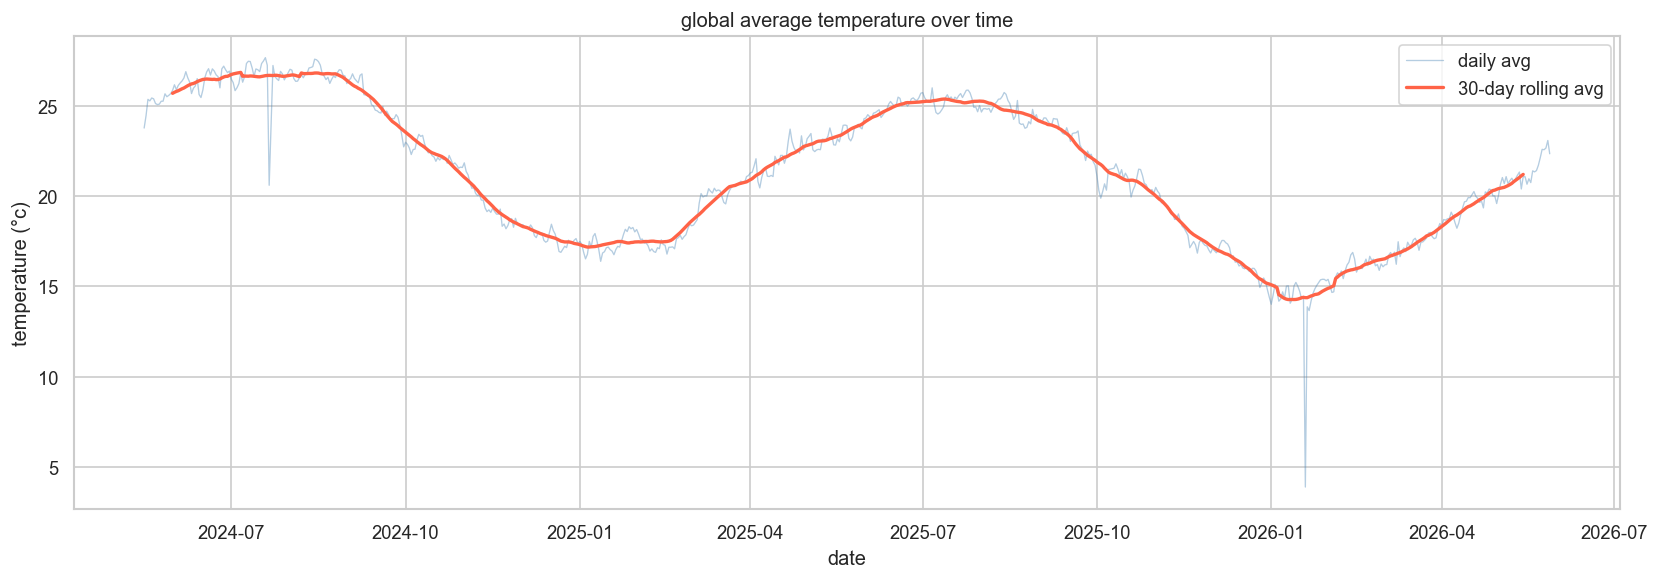

In [65]:
daily_temp = df.groupby('date')['temperature_celsius'].mean().reset_index()
daily_temp.columns = ['date', 'avg_temp']
daily_temp['rolling_30'] = daily_temp['avg_temp'].rolling(30, center=True).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily_temp['date'], daily_temp['avg_temp'],
        alpha=0.4, color='steelblue', linewidth=0.8, label='daily avg')
ax.plot(daily_temp['date'], daily_temp['rolling_30'],
        color='tomato', linewidth=2, label='30-day rolling avg')
ax.set_title('global average temperature over time')
ax.set_xlabel('date')
ax.set_ylabel('temperature (°c)')
ax.legend()
plt.tight_layout()
plt.show()


Break down average temperature, precipitation and humidity by calendar month to see seasonality clearly across all cities in the dataset.

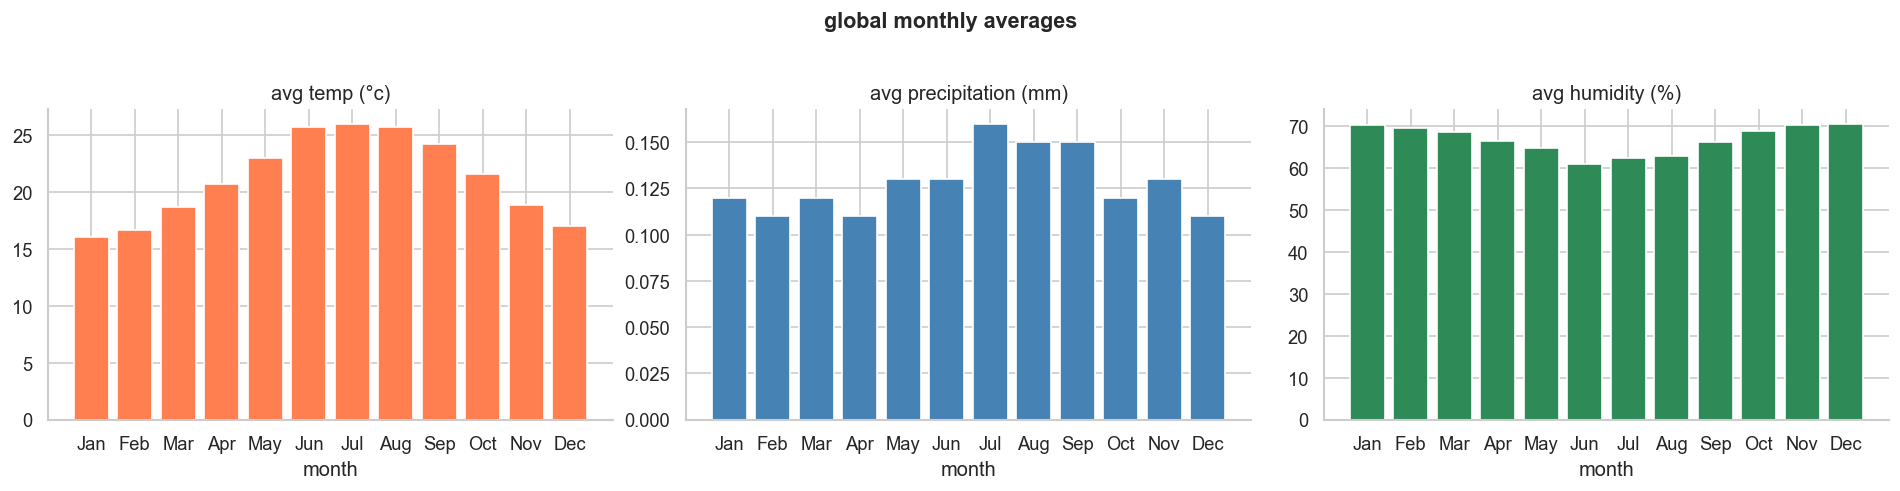

In [66]:
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly = df.groupby('month')[['temperature_celsius','precip_mm','humidity']].mean().round(2)
monthly.index = month_names

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
pairs = [
    ('temperature_celsius', 'coral', 'avg temp (°c)'),
    ('precip_mm', 'steelblue', 'avg precipitation (mm)'),
    ('humidity', 'seagreen', 'avg humidity (%)')
]
for ax, (col, color, label) in zip(axes, pairs):
    ax.bar(month_names, monthly[col], color=color, edgecolor='white')
    ax.set_title(label)
    ax.set_xlabel('month')
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

plt.suptitle('global monthly averages', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


Boxplot of temperature distribution per continent  gives us median, spread and outliers at a glance. Sorted by median so the hottest continents appear first.

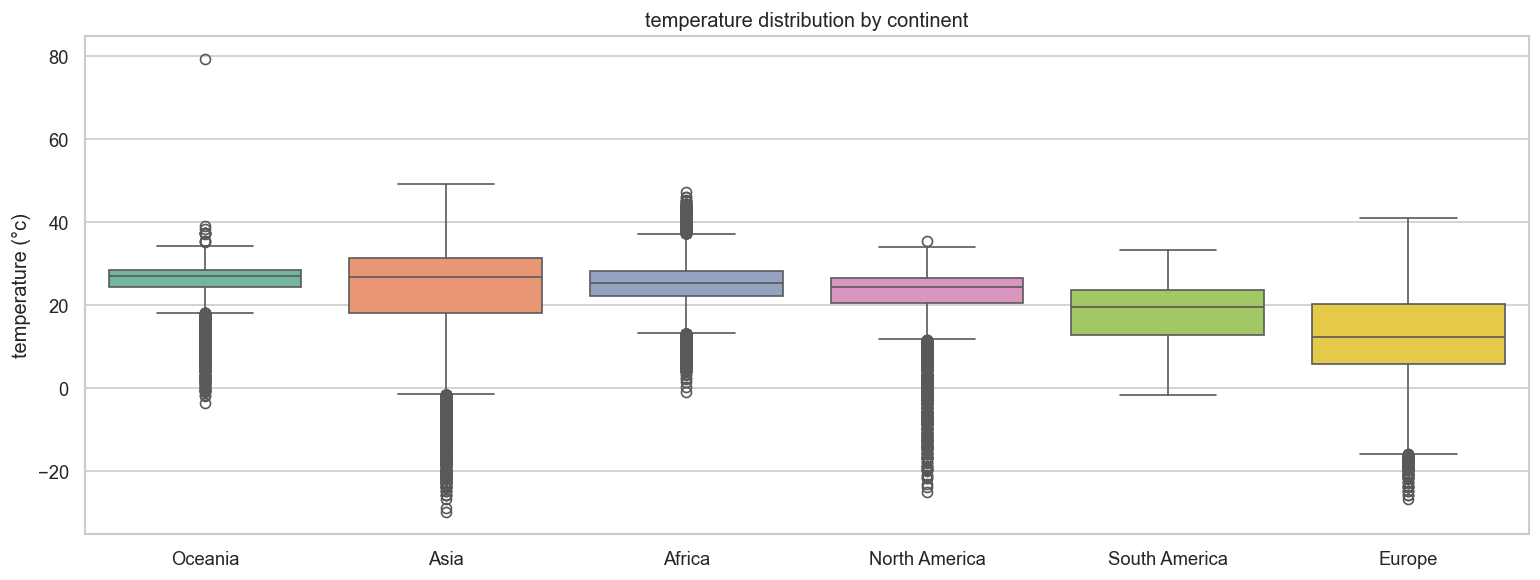

In [67]:
order = (df[df['continent'] != 'Other']
         .groupby('continent')['temperature_celsius']
         .median()
         .sort_values(ascending=False)
         .index.tolist())

fig, ax = plt.subplots(figsize=(13, 5))
sns.boxplot(data=df[df['continent'] != 'Other'],
            x='continent', y='temperature_celsius',
            order=order, palette='Set2', ax=ax)
ax.set_title('temperature distribution by continent')
ax.set_xlabel('')
ax.set_ylabel('temperature (°c)')
plt.tight_layout()
plt.show()


Correlation heatmap across the main weather and air quality features. Masking the upper triangle avoids redundancy and makes it easier to read.

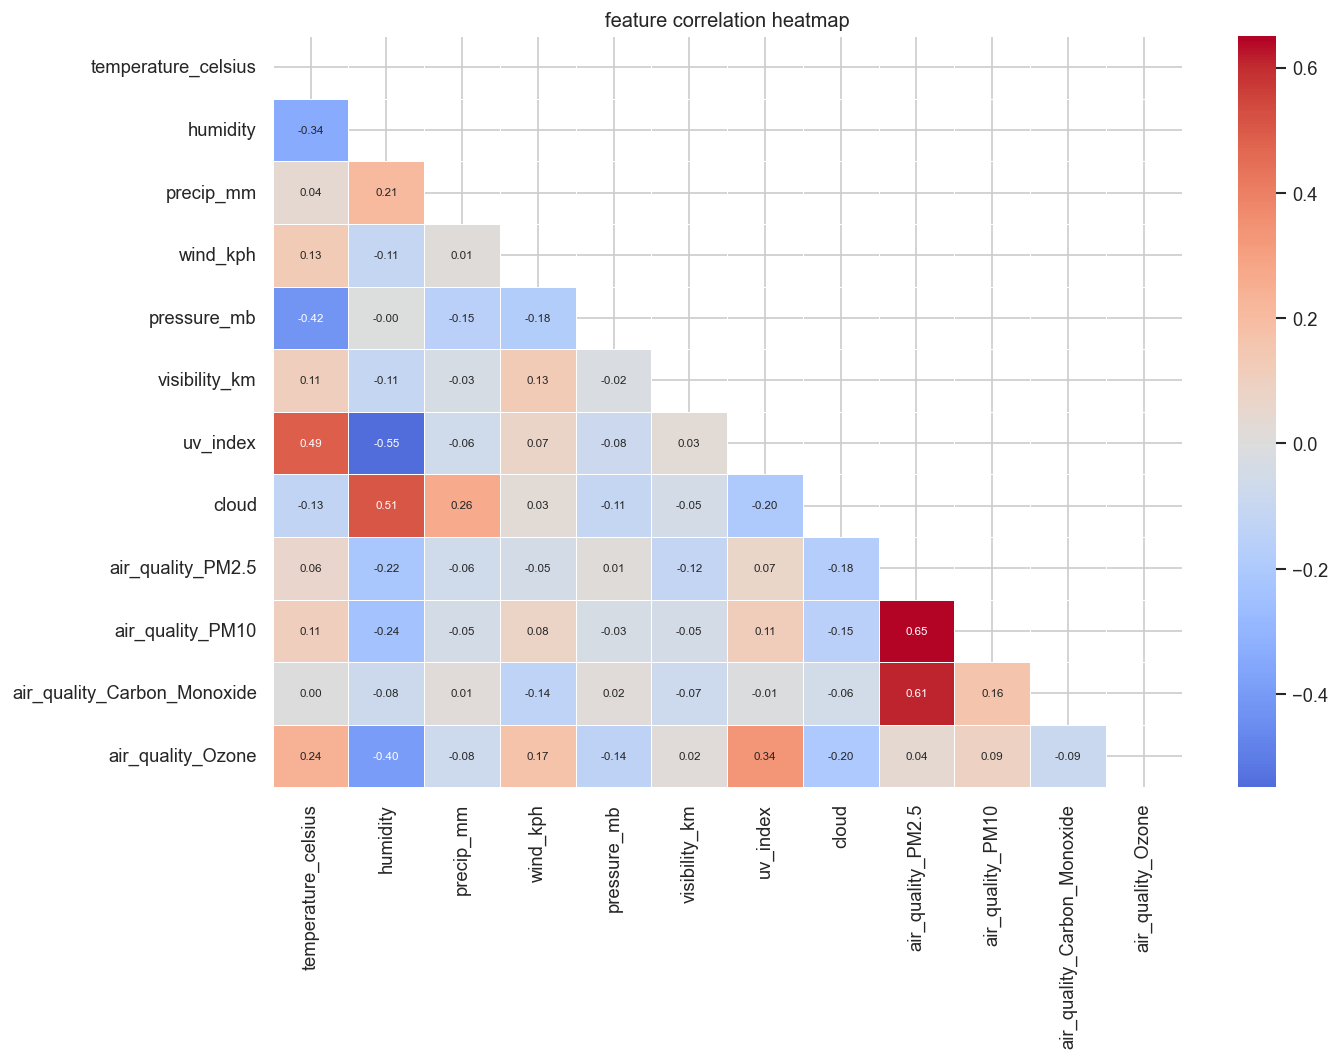

In [68]:
corr_cols = ['temperature_celsius','humidity','precip_mm','wind_kph',
             'pressure_mb','visibility_km','uv_index','cloud',
             'air_quality_PM2.5','air_quality_PM10',
             'air_quality_Carbon_Monoxide','air_quality_Ozone']
corr_cols = [c for c in corr_cols if c in df.columns]

corr = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 7})
ax.set_title('feature correlation heatmap')
plt.tight_layout()
plt.show()


Find the 15 capitals with the highest average daily precipitation. Useful for later spatial analysis and for understanding which regions drive the precip signal.

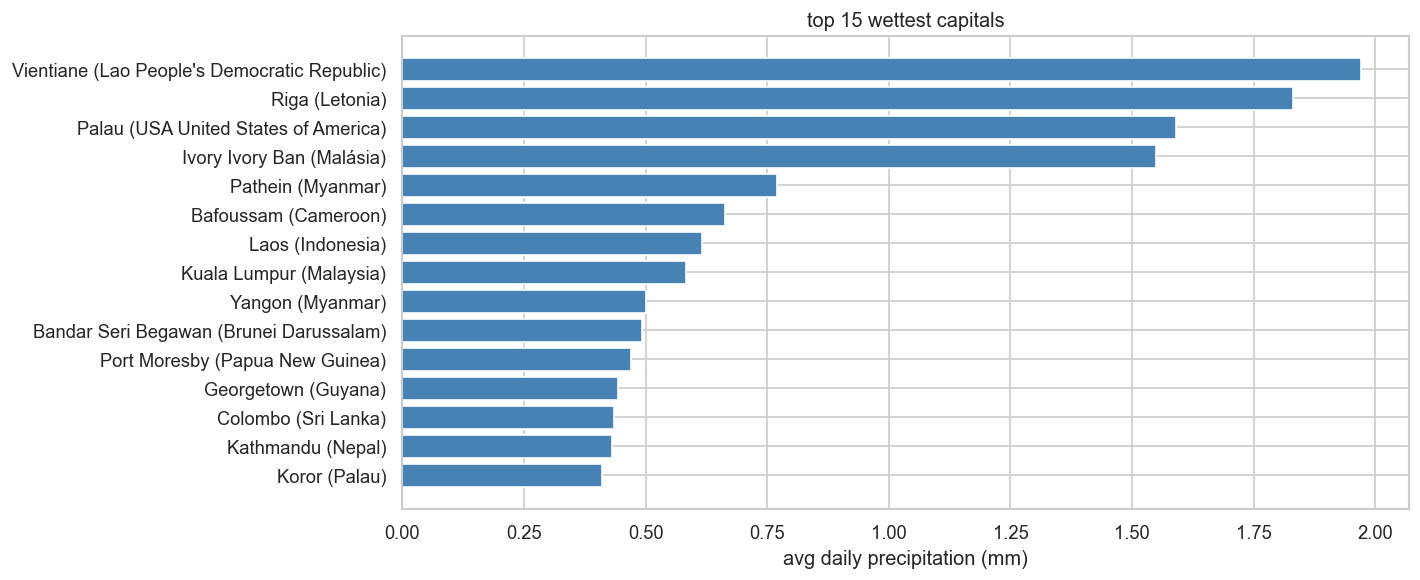

In [69]:
precip_city = (df.groupby(['country','location_name'])['precip_mm']
               .mean().reset_index())
precip_city.columns = ['country','city','avg_precip_mm']
top15_wet = precip_city.nlargest(15, 'avg_precip_mm')

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(top15_wet['city'] + ' (' + top15_wet['country'] + ')',
        top15_wet['avg_precip_mm'], color='steelblue')
ax.set_xlabel('avg daily precipitation (mm)')
ax.set_title('top 15 wettest capitals')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


Weather condition frequency  shows which conditions dominate globally and helps understand class balance if we ever want to build a classifier later.

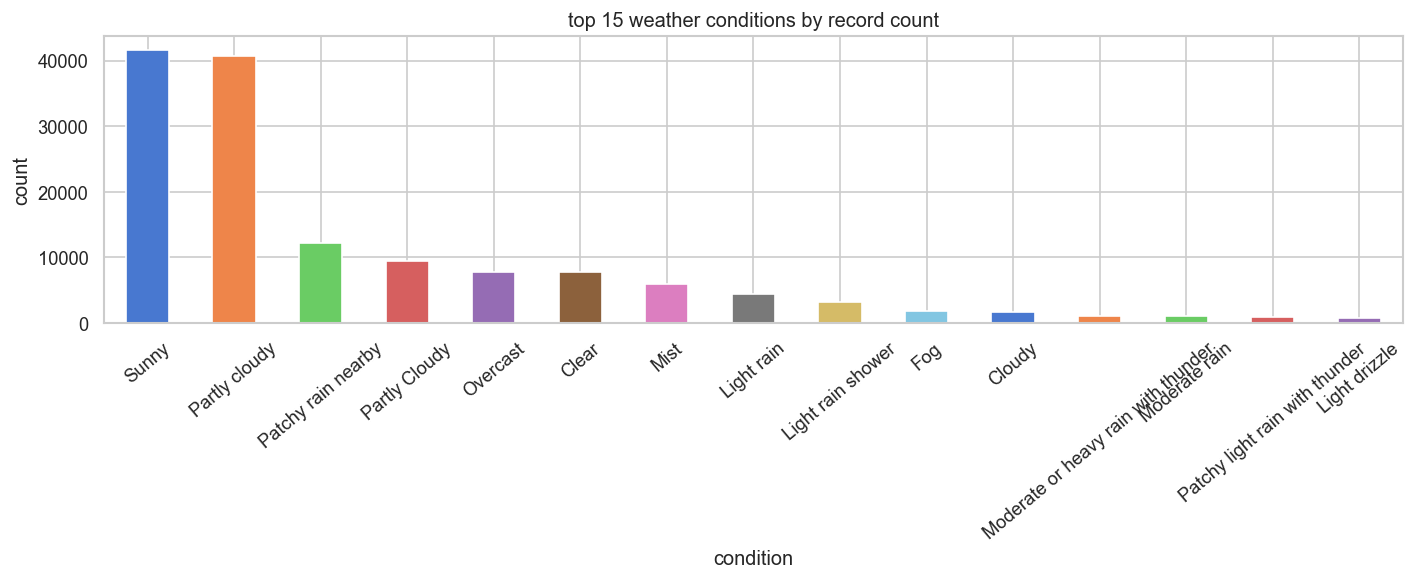

In [70]:
cond_counts = df['condition_text'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 5))
cond_counts.plot(kind='bar', ax=ax, color=sns.color_palette('muted', 15))
ax.set_title('top 15 weather conditions by record count')
ax.set_xlabel('condition')
ax.set_ylabel('count')
ax.tick_params(axis='x', rotation=40)
plt.tight_layout()
plt.show()


Violin plot of wind speed per continent. The inner quartile lines show median and IQR while the shape gives us the full distribution  more informative than a plain boxplot for wind which tends to be skewed.

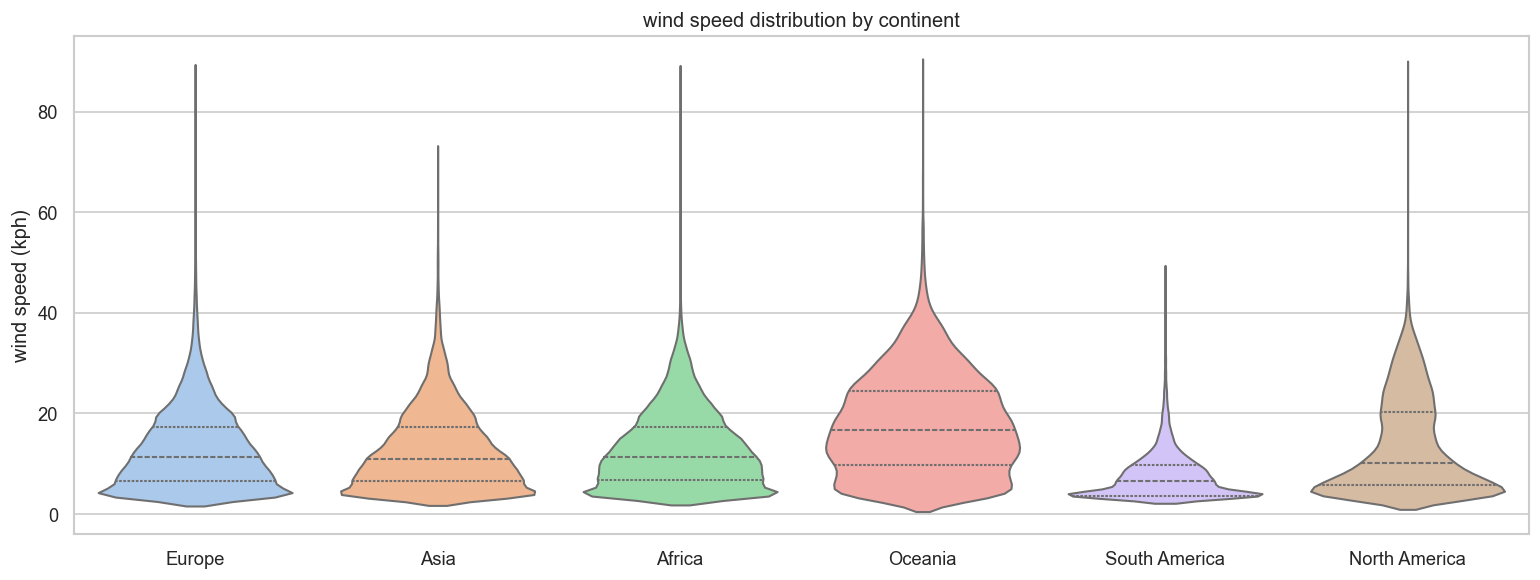

In [71]:
fig, ax = plt.subplots(figsize=(13, 5))
sns.violinplot(data=df[df['continent'] != 'Other'],
               x='continent', y='wind_kph',
               palette='pastel', inner='quartile', ax=ax)
ax.set_title('wind speed distribution by continent')
ax.set_xlabel('')
ax.set_ylabel('wind speed (kph)')
plt.tight_layout()
plt.show()


Interactive scatter of humidity vs temperature coloured by continent. We sample 5000 rows so plotly stays responsive  the pattern is clear enough at that scale.

In [72]:
# [perf] sampling to 5k rows keeps the plotly chart snappy in the browser
sample = df.sample(min(5000, len(df)), random_state=42)

fig = px.scatter(sample, x='temperature_celsius', y='humidity',
                 color='continent', opacity=0.5,
                 labels={'temperature_celsius': 'temperature (°c)', 'humidity': 'humidity (%)'},
                 title='humidity vs temperature by continent')
fig.show()


## 4. Anomaly detection

Isolation forest works by randomly partitioning the feature space  anomalies are points that get isolated in fewer splits. We run it on 6 core weather features after standard scaling so no single feature dominates.

In [73]:
anomaly_features = ['temperature_celsius','humidity','precip_mm',
                    'wind_kph','pressure_mb','visibility_km']
anomaly_features = [c for c in anomaly_features if c in df.columns]

X_anom = df[anomaly_features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_anom)

# [note] contamination=0.02 means we expect ~2% of records to be outliers
iso = IsolationForest(n_estimators=200, contamination=0.02, random_state=42, n_jobs=-1)
df['anomaly'] = iso.fit_predict(X_scaled)
df['anomaly_score'] = iso.decision_function(X_scaled)

n_anom = (df['anomaly'] == -1).sum()
print(f"anomalies flagged: {n_anom} ({n_anom/len(df)*100:.2f}% of records)")


anomalies flagged: 2881 (2.00% of records)


Overlay anomalous points on the temperature timeline. We're looking for whether they cluster around specific time periods (storm seasons, heatwaves) or scatter randomly.

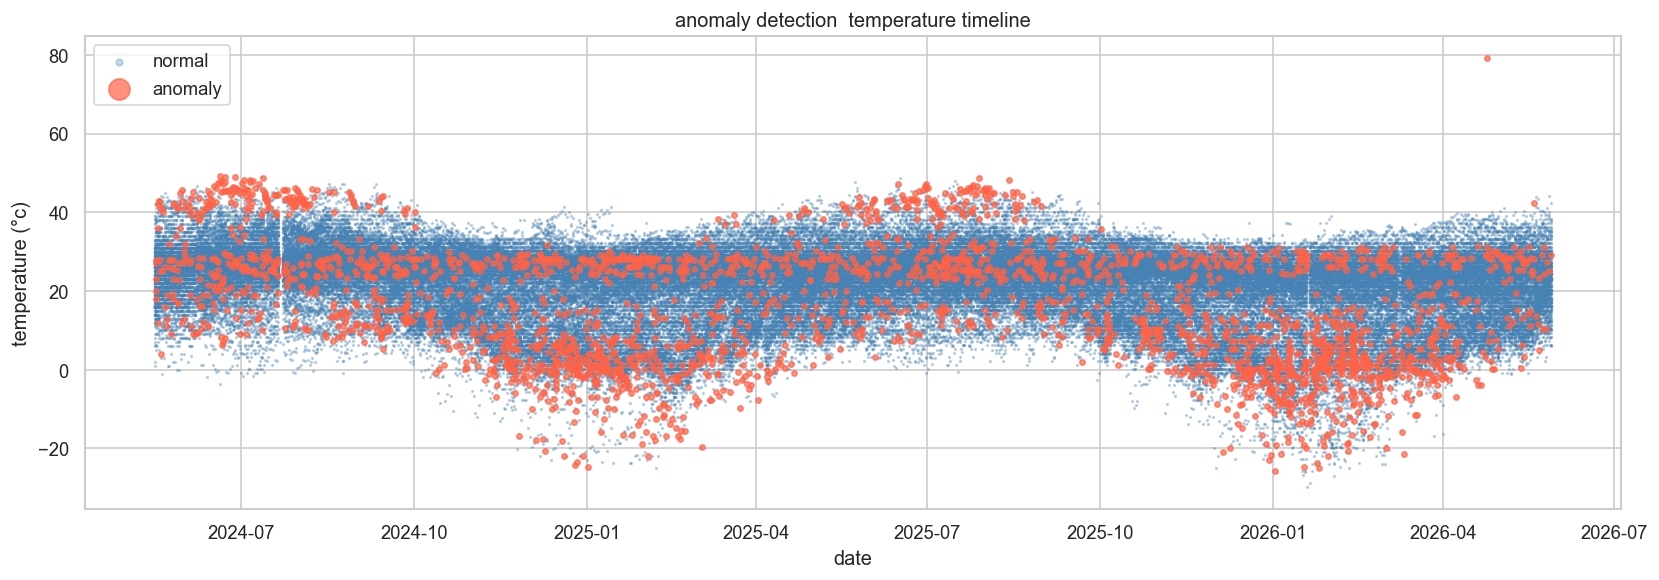

In [74]:
normal = df[df['anomaly'] == 1]
anom   = df[df['anomaly'] == -1]

fig, ax = plt.subplots(figsize=(14, 5))
ax.scatter(normal['last_updated'], normal['temperature_celsius'],
           s=1, alpha=0.3, color='steelblue', label='normal')
ax.scatter(anom['last_updated'], anom['temperature_celsius'],
           s=10, alpha=0.7, color='tomato', label='anomaly')
ax.set_title('anomaly detection  temperature timeline')
ax.set_xlabel('date')
ax.set_ylabel('temperature (°c)')
ax.legend(markerscale=4)
plt.tight_layout()
plt.show()


Which countries have the most flagged records? High counts might reflect genuinely volatile climates, data quality issues, or edge cases in the isolation forest on small populations.

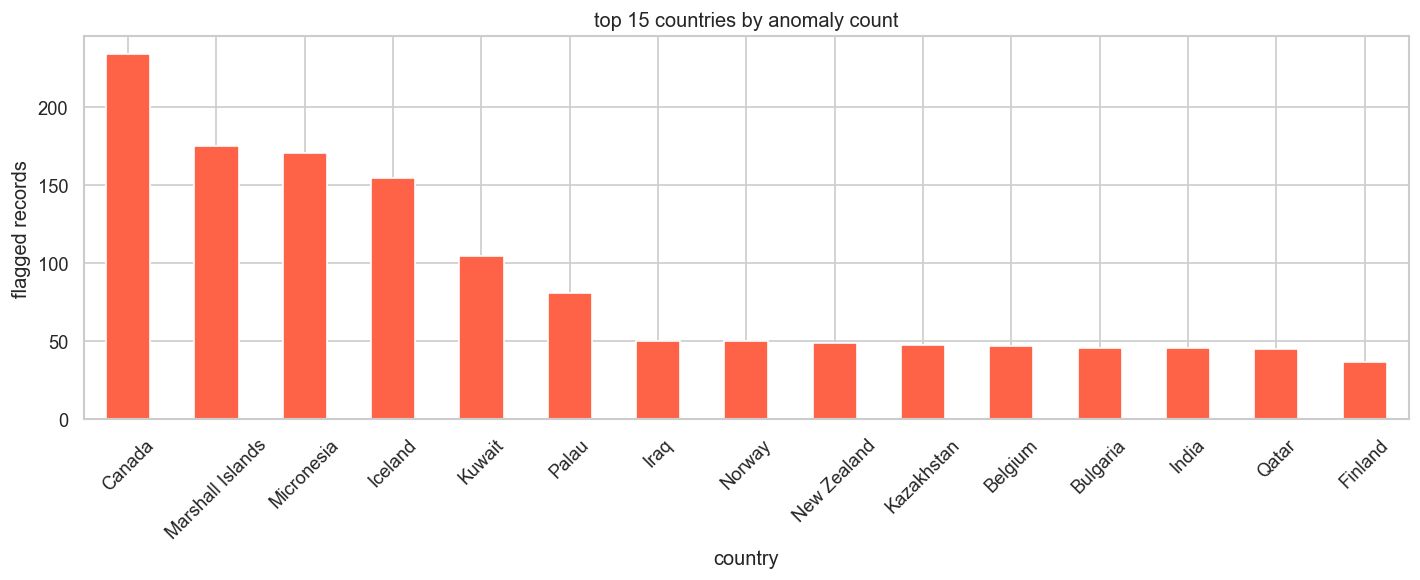

In [75]:
anom_by_country = (df[df['anomaly'] == -1]
                   .groupby('country').size()
                   .sort_values(ascending=False)
                   .head(15))

fig, ax = plt.subplots(figsize=(12, 5))
anom_by_country.plot(kind='bar', ax=ax, color='tomato', edgecolor='white')
ax.set_title('top 15 countries by anomaly count')
ax.set_ylabel('flagged records')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


Z-score based extreme event check  complementary to isolation forest since it's univariate and interpretable. Anything beyond ±3 standard deviations is worth a closer look.

In [77]:
# [debug] z-score is a quick sanity check  if isolation forest and z-score agree, we're more confident
df['temp_zscore'] = ((df['temperature_celsius'] - df['temperature_celsius'].mean())
                     / df['temperature_celsius'].std())

extreme = df[df['temp_zscore'].abs() > 3][
    ['country','location_name','last_updated','temperature_celsius','temp_zscore']
].sort_values('temp_zscore')

print("extreme cold events (z < -3):")
print(extreme.head(5).to_string(index=False))
print("extreme heat events (z > 3):")
print(extreme.tail(5).to_string(index=False))


extreme cold events (z < -3):
 country location_name        last_updated  temperature_celsius  temp_zscore
Mongolia   Ulaanbaatar 2026-01-18 15:00:00                -29.8    -5.311069
Mongolia   Ulaanbaatar 2026-01-20 15:15:00                -28.9    -5.217439
 Belarus         Minsk 2026-02-02 10:00:00                -26.9    -5.009372
Mongolia   Ulaanbaatar 2026-01-16 15:15:00                -26.8    -4.998968
Mongolia   Ulaanbaatar 2026-01-17 15:00:00                -25.9    -4.905338
extreme heat events (z > 3):
     country    location_name        last_updated  temperature_celsius  temp_zscore
     Croatia           Zagreb 2025-12-31 08:00:00                 -7.6    -3.001525
      Canada           Ottawa 2024-12-27 05:45:00                 -7.6    -3.001525
      Norway             Oslo 2024-11-22 09:45:00                 -7.6    -3.001525
     Andorra Andorra La Vella 2026-02-17 07:45:00                 -7.6    -3.001525
Fiji Islands             Suva 2026-04-24 18:30:00          

## 5. Time series forecasting

We forecast global average daily temperature using five approaches and then blend them into a weighted ensemble.
- Baseline: linear regression with sine/cosine seasonal terms
- SARIMA: classical time series via statsmodels
- XGBoost: gradient boosting with lag and rolling features
- LightGBM: faster gradient boosting, same feature set
- Prophet (optional): trend + changepoint decomposition
- Ensemble: weighted average inversely proportional to each model's MAE


Build the daily global average series that all models will train on. We sort by date and drop any NaN rows (shouldn't be any after cleaning, but good habit).

In [78]:
ts = (df.groupby('date')['temperature_celsius']
        .mean()
        .reset_index()
        .sort_values('date')
        .dropna())
ts.columns = ['ds', 'y']

print(f"time series length: {len(ts)} days")
ts.tail(5)


time series length: 742 days


,ds,y
737,2026-05-24,22.588144
738,2026-05-25,22.567179
739,2026-05-26,22.660513
740,2026-05-27,23.078462
741,2026-05-28,22.343299


Hold out the last 60 days as a test set. We train on everything before that and evaluate all models on the same unseen window so comparisons are fair.

In [79]:
FORECAST_DAYS = 60
train = ts.iloc[:-FORECAST_DAYS].copy()
test  = ts.iloc[-FORECAST_DAYS:].copy()

print(f"train: {train['ds'].min().date()} -> {train['ds'].max().date()} ({len(train)} days)")
print(f"test:  {test['ds'].min().date()} -> {test['ds'].max().date()} ({len(test)} days)")


train: 2024-05-16 -> 2026-03-29 (682 days)
test:  2026-03-30 -> 2026-05-28 (60 days)


Feature engineering for the tree-based models. We encode seasonality using sine/cosine transforms (avoids the discontinuity at month/year boundaries) and add lag and rolling features to give the models temporal context.

In [80]:
def make_features(df_ts):
    d = df_ts.copy()
    d['t'] = np.arange(len(d))
    d['month'] = d['ds'].dt.month
    d['dayofyear'] = d['ds'].dt.dayofyear
    # [note] sin/cos encoding wraps the calendar so dec->jan is continuous
    d['sin_doy']   = np.sin(2 * np.pi * d['dayofyear'] / 365)
    d['cos_doy']   = np.cos(2 * np.pi * d['dayofyear'] / 365)
    d['sin_month'] = np.sin(2 * np.pi * d['month'] / 12)
    d['cos_month'] = np.cos(2 * np.pi * d['month'] / 12)
    for lag in [1, 7, 14, 30]:
        d[f'lag_{lag}'] = d['y'].shift(lag)
    d['rolling_7']  = d['y'].shift(1).rolling(7).mean()
    d['rolling_14'] = d['y'].shift(1).rolling(14).mean()
    return d

feat_cols = ['t','sin_doy','cos_doy','sin_month','cos_month',
             'lag_1','lag_7','lag_14','lag_30','rolling_7','rolling_14']

full_feat  = make_features(ts)
train_feat = full_feat.iloc[:-FORECAST_DAYS].dropna()
test_feat  = full_feat.iloc[-FORECAST_DAYS:].copy()

X_train = train_feat[feat_cols]
y_train = train_feat['y']
X_test  = test_feat[feat_cols].ffill().bfill()
y_test  = test['y'].values


Shared evaluation function so we log mae, rmse and r² consistently for every model without repeating ourselves.

In [81]:
def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"[{name}]  mae={mae:.3f}°c  rmse={rmse:.3f}°c  r²={r2:.4f}")
    return {'model': name, 'mae': mae, 'rmse': rmse, 'r2': r2}

results = []
predictions = {}


Baseline: linear regression using just the time index and sine/cosine seasonality. This gives us a floor  any decent model should beat it.

In [82]:
lr = LinearRegression()
lr.fit(X_train[['t','sin_doy','cos_doy']], y_train)
pred_lr = lr.predict(test_feat[['t','sin_doy','cos_doy']].fillna(0))
predictions['linear regression'] = pred_lr
results.append(evaluate('linear regression', y_test, pred_lr))


[linear regression]  mae=0.354°c  rmse=0.449°c  r²=0.8589


SARIMA  a classical time series model that captures autocorrelation and moving average structure. We use order (2,1,2) which is a reasonable starting point for a temperature series with 30-ish day periodicity.

In [83]:
try:
    sarima_model = SARIMAX(
        train['y'].values,
        order=(2, 1, 2),
        seasonal_order=(0, 0, 0, 0),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    sarima_fit = sarima_model.fit(disp=False)
    pred_sarima = sarima_fit.forecast(steps=FORECAST_DAYS)
    predictions['sarima'] = pred_sarima
    results.append(evaluate('sarima', y_test, pred_sarima))
except Exception as e:
    print(f"sarima failed: {e}")
    pred_sarima = None


[sarima]  mae=2.568°c  rmse=2.832°c  r²=-4.6210


XGBoost with the lag/rolling feature set. We add the test set as an eval set so we can inspect learning curves if needed, but we don't use early stopping here to keep things deterministic.

In [84]:
xgb_model = xgb.XGBRegressor(
    n_estimators=500, learning_rate=0.05,
    max_depth=4, subsample=0.8,
    colsample_bytree=0.8, random_state=42,
    verbosity=0
)
xgb_model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              verbose=False)
pred_xgb = xgb_model.predict(X_test)
predictions['xgboost'] = pred_xgb
results.append(evaluate('xgboost', y_test, pred_xgb))


[xgboost]  mae=0.350°c  rmse=0.431°c  r²=0.8696


LightGBM  same feature set as xgboost but typically trains faster and handles larger datasets more efficiently. Good to compare both since they can behave differently on time series.

In [85]:
lgb_model = lgb.LGBMRegressor(
    n_estimators=500, learning_rate=0.05,
    max_depth=4, subsample=0.8,
    colsample_bytree=0.8, random_state=42,
    verbose=-1
)
lgb_model.fit(X_train, y_train)
pred_lgb = lgb_model.predict(X_test)
predictions['lightgbm'] = pred_lgb
results.append(evaluate('lightgbm', y_test, pred_lgb))


[lightgbm]  mae=0.287°c  rmse=0.361°c  r²=0.9089


Prophet if it's installed. It automatically detects yearly seasonality and change points in the trend  handy for a dataset that spans two full years.

In [86]:
if PROPHET_AVAILABLE:
    prophet_model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        changepoint_prior_scale=0.1
    )
    prophet_model.fit(train.rename(columns={'ds': 'ds', 'y': 'y'}))
    future = prophet_model.make_future_dataframe(periods=FORECAST_DAYS)
    fc = prophet_model.predict(future)
    pred_prophet = fc['yhat'].values[-FORECAST_DAYS:]
    predictions['prophet'] = pred_prophet
    results.append(evaluate('prophet', y_test, pred_prophet))
else:
    print("prophet not available, skipping")


22:07:50 - cmdstanpy - INFO - Chain [1] start processing
22:07:50 - cmdstanpy - INFO - Chain [1] done processing
22:07:50 - cmdstanpy - ERROR - Chain [1] error: code '3221225785' 
Optimization terminated abnormally. Falling back to Newton.
22:07:50 - cmdstanpy - INFO - Chain [1] start processing
22:07:50 - cmdstanpy - INFO - Chain [1] done processing
22:07:50 - cmdstanpy - ERROR - Chain [1] error: code '3221225785' 


RuntimeError: Error during optimization! Command 'E:\PMassesment\.venv\Lib\site-packages\prophet\stan_model\prophet_model.bin random seed=2716 data file=C:\Users\YAXITA\AppData\Local\Temp\tmpcrx9cvl5\46u2l8ro.json init=C:\Users\YAXITA\AppData\Local\Temp\tmpcrx9cvl5\i9x867tg.json output file=C:\Users\YAXITA\AppData\Local\Temp\tmpcrx9cvl5\prophet_modelit_c3h_z\prophet_model-20260528220750.csv method=optimize algorithm=newton iter=10000' failed: 

Ensemble: combine all models using inverse-MAE weighting so better-performing models get more influence. This is a simple but effective blending strategy.

In [ ]:
preds_list = []
weights    = []

for name, pred in predictions.items():
    r = next(r for r in results if r['model'] == name)
    w = 1.0 / (r['mae'] + 1e-6)
    preds_list.append(pred * w)
    weights.append(w)

pred_ensemble = np.sum(preds_list, axis=0) / np.sum(weights)
predictions['ensemble'] = pred_ensemble
results.append(evaluate('ensemble', y_test, pred_ensemble))


Summary table and bar charts comparing mae, rmse and r² across all models. The ensemble bar should come out on top (or very close to the best individual model).

In [ ]:
results_df = pd.DataFrame(results).sort_values('rmse')
print("model comparison:")
print(results_df.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ['mae', 'rmse', 'r2']):
    colors = ['seagreen' if m == 'ensemble' else 'steelblue' for m in results_df['model']]
    ax.barh(results_df['model'], results_df[metric], color=colors)
    ax.set_title(metric.upper())
    ax.invert_yaxis()
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

plt.suptitle('model performance comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


Visual forecast plot overlaying all model predictions against the actual test period. Using the last 120 train days as context so we can see how the predictions transition.

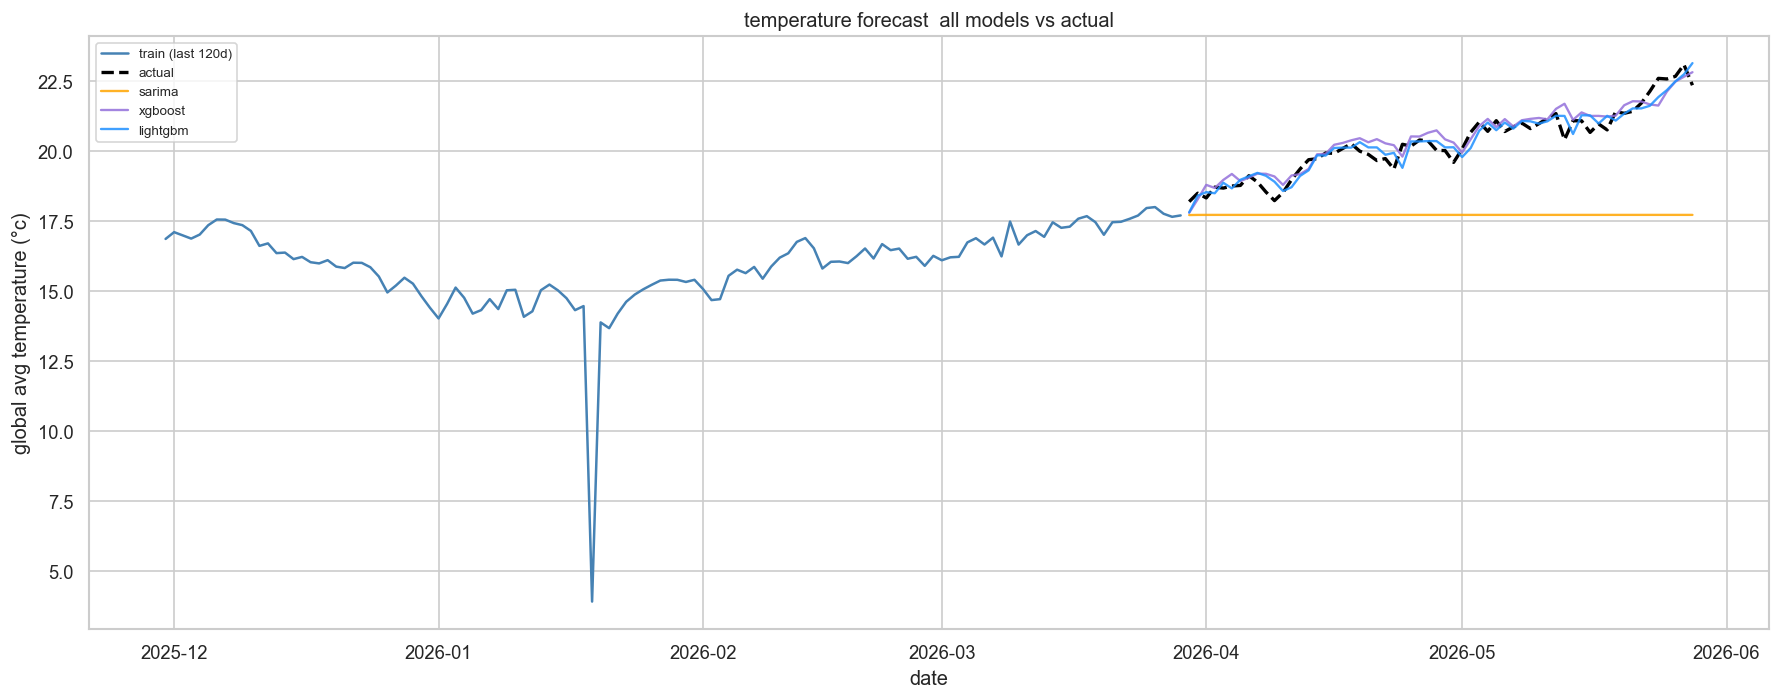

In [87]:
plot_colors = {
    'sarima': 'orange', 'xgboost': 'mediumpurple',
    'lightgbm': 'dodgerblue', 'prophet': 'pink',
    'ensemble': 'tomato', 'linear regression': 'grey'
}

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(train['ds'].values[-120:], train['y'].values[-120:],
        color='steelblue', label='train (last 120d)', linewidth=1.5)
ax.plot(test['ds'].values, y_test,
        color='black', linewidth=2, linestyle='--', label='actual')

for name, pred in predictions.items():
    if name != 'linear regression':
        ax.plot(test['ds'].values, pred, label=name,
                linewidth=1.4, alpha=0.85, color=plot_colors.get(name, 'green'))

ax.set_title('temperature forecast  all models vs actual')
ax.set_xlabel('date')
ax.set_ylabel('global avg temperature (°c)')
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()


## 6. Climate pattern analysis

Decompose the global daily temperature series into trend, seasonal and residual components using an additive model with a 30-day period.

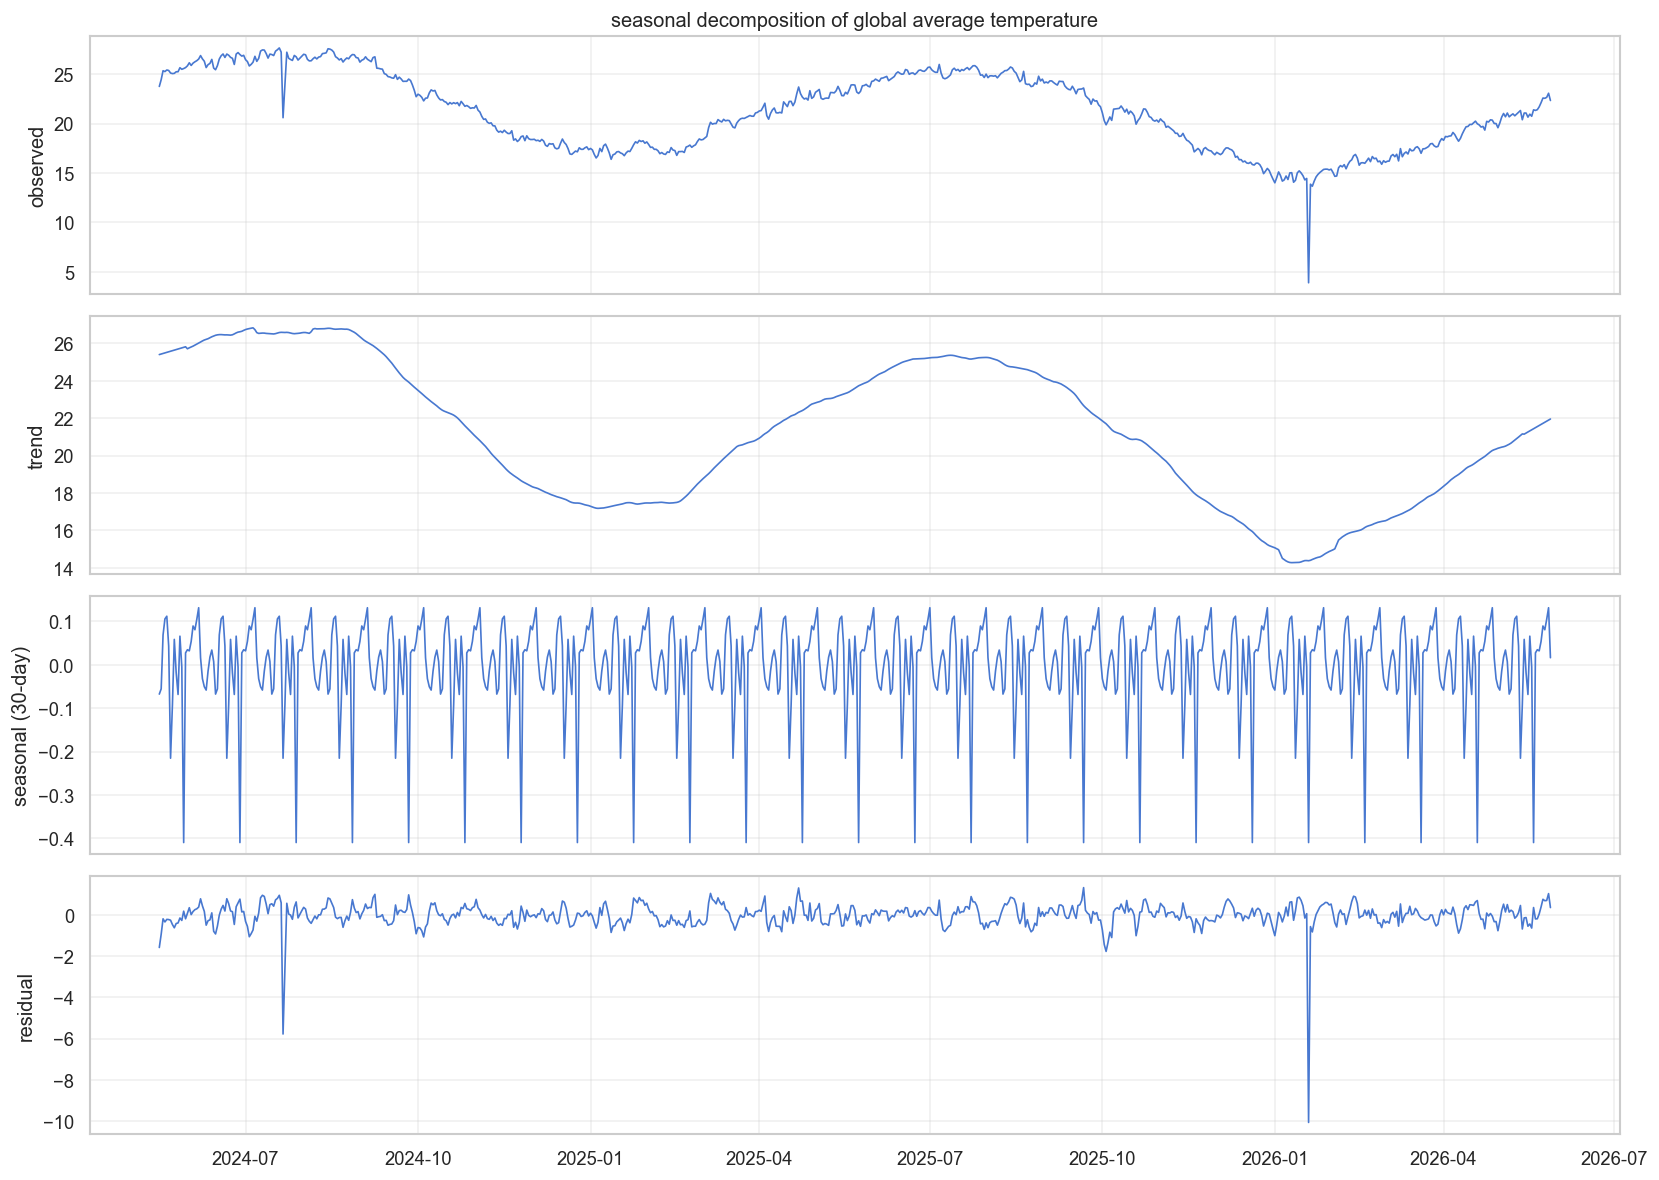

In [88]:
ts_full = ts.set_index('ds')['y'].asfreq('D').interpolate()
decomp = seasonal_decompose(ts_full, model='additive', period=30, extrapolate_trend='freq')

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
labels = ['observed', 'trend', 'seasonal (30-day)', 'residual']
components = [decomp.observed, decomp.trend, decomp.seasonal, decomp.resid]

for ax, label, data in zip(axes, labels, components):
    ax.plot(data, linewidth=1)
    ax.set_ylabel(label)
    ax.grid(True, alpha=0.3)

axes[0].set_title('seasonal decomposition of global average temperature')
plt.tight_layout()
plt.show()


Monthly average temperature per continent over time  shows whether warming trends differ by region and makes it easy to spot seasonal inversions between hemispheres.

In [89]:
cont_monthly = (df[df['continent'] != 'Other']
                .groupby(['continent','year','month'])['temperature_celsius']
                .mean().reset_index())
cont_monthly['period'] = pd.to_datetime(
    cont_monthly['year'].astype(str) + '-' +
    cont_monthly['month'].astype(str).str.zfill(2) + '-01'
)

fig = px.line(cont_monthly.sort_values('period'),
              x='period', y='temperature_celsius', color='continent',
              labels={'temperature_celsius': 'avg temp (°c)', 'period': 'month'},
              title='monthly average temperature by continent over time')
fig.update_traces(line=dict(width=1.5))
fig.show()


Temperature variability (standard deviation) per country  high std means the country's capital experiences large swings across the dataset, which could reflect seasonality or data anomalies.

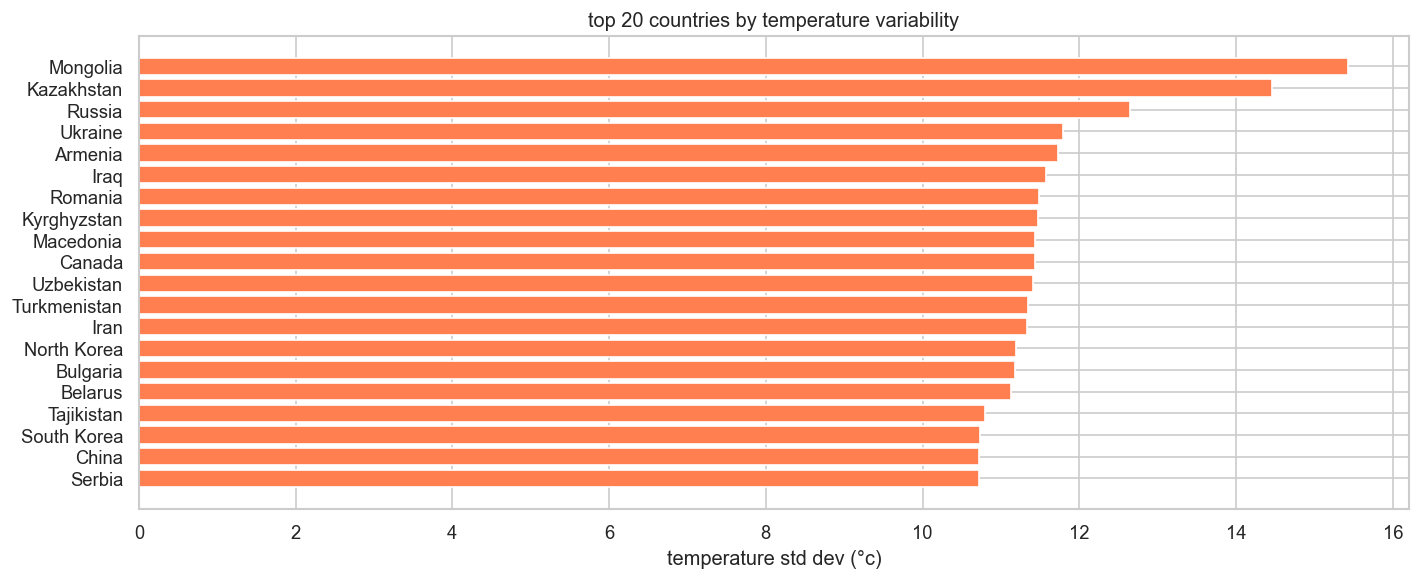

In [90]:
variability = (df.groupby('country')['temperature_celsius']
               .std().sort_values(ascending=False).head(20).reset_index())
variability.columns = ['country', 'temp_std']

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(variability['country'], variability['temp_std'], color='coral')
ax.set_xlabel('temperature std dev (°c)')
ax.set_title('top 20 countries by temperature variability')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


Highlight which calendar month is hottest and coldest globally. The red bar = peak, blue = trough, grey = everything else.

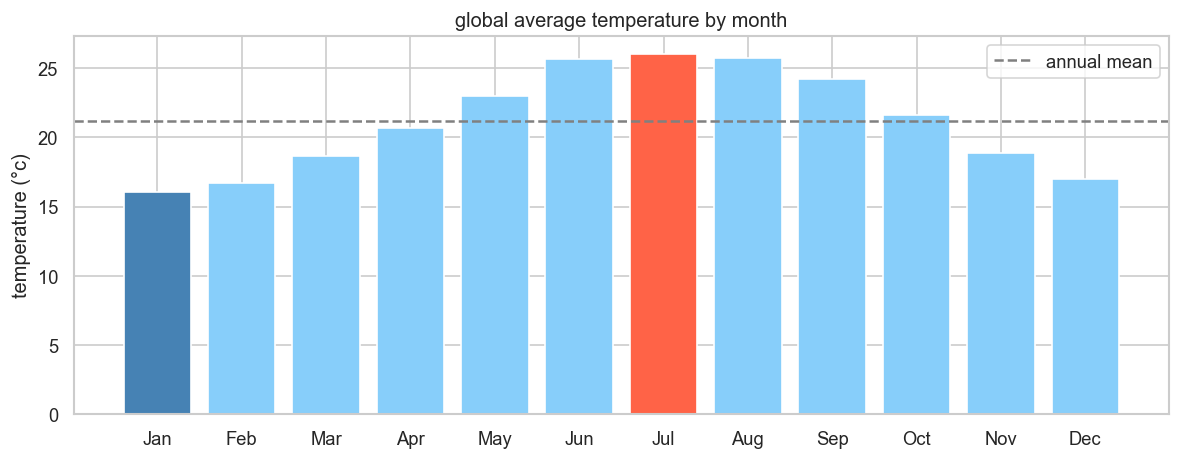

In [91]:
monthly_global = df.groupby('month')['temperature_celsius'].mean()
monthly_global.index = month_names

fig, ax = plt.subplots(figsize=(10, 4))
bar_colors = [
    'tomato' if v == monthly_global.max() else
    'steelblue' if v == monthly_global.min() else
    'lightskyblue'
    for v in monthly_global
]
ax.bar(month_names, monthly_global, color=bar_colors)
ax.axhline(monthly_global.mean(), color='grey', linestyle='--', label='annual mean')
ax.set_title('global average temperature by month')
ax.set_ylabel('temperature (°c)')
ax.legend()
plt.tight_layout()
plt.show()


## 7. Air quality & environmental impact

Quick overview of all air quality columns available in the dataset.

In [92]:
aq_features = [c for c in df.columns if 'air_quality' in c and 'index' not in c.lower()]
print("air quality columns:", aq_features)
df[aq_features].describe().round(2)


air quality columns: ['air_quality_Carbon_Monoxide', 'air_quality_Ozone', 'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10']


,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10
count,144042.00,144042.00,144042.00,144042.00,144042.00,144042.00
mean,448.35,57.48,14.79,10.09,23.81,47.70
std,741.43,30.37,23.28,34.67,36.20,147.18
min,-9999.00,0.00,0.00,-9999.00,0.17,-1848.15
25%,194.25,38.00,1.80,1.11,7.03,9.80
50%,286.75,55.00,5.74,2.40,13.88,19.60
75%,449.55,73.00,17.02,8.05,27.35,40.80
max,38879.40,480.70,427.70,521.33,1614.10,6037.29


Average PM2.5 per continent plotted against the WHO annual guideline (12 μg/m³) and the 24-hour unhealthy threshold (35 μg/m³). Makes it immediately obvious which regions exceed safe levels.

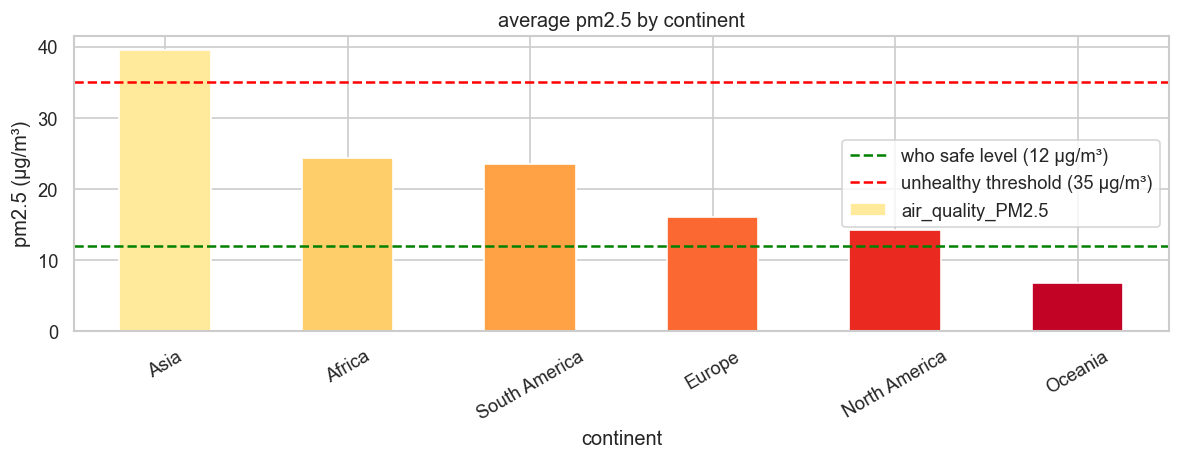

In [93]:
if 'air_quality_PM2.5' in df.columns:
    pm_cont = (df[df['continent'] != 'Other']
               .groupby('continent')['air_quality_PM2.5']
               .mean().sort_values(ascending=False))

    fig, ax = plt.subplots(figsize=(10, 4))
    pm_cont.plot(kind='bar', ax=ax, color=sns.color_palette('YlOrRd', len(pm_cont)))
    ax.axhline(12, color='green', linestyle='--', label='who safe level (12 μg/m³)')
    ax.axhline(35, color='red',   linestyle='--', label='unhealthy threshold (35 μg/m³)')
    ax.set_title('average pm2.5 by continent')
    ax.set_ylabel('pm2.5 (μg/m³)')
    ax.tick_params(axis='x', rotation=30)
    ax.legend()
    plt.tight_layout()
    plt.show()


Global PM2.5 trend over time with a 30-day rolling average. We want to see if air quality is improving or worsening across the dataset window.

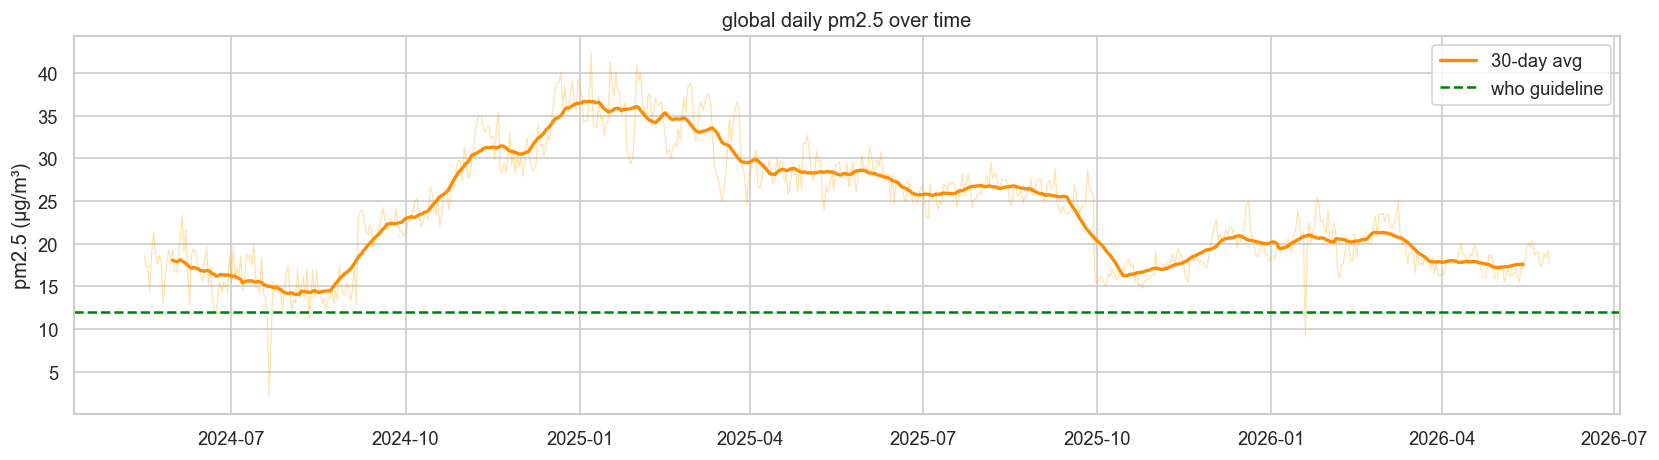

In [94]:
if 'air_quality_PM2.5' in df.columns:
    pm_daily = df.groupby('date')['air_quality_PM2.5'].mean().reset_index()
    pm_daily['rolling_30'] = pm_daily['air_quality_PM2.5'].rolling(30, center=True).mean()

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(pm_daily['date'], pm_daily['air_quality_PM2.5'],
            alpha=0.3, color='orange', linewidth=0.8)
    ax.plot(pm_daily['date'], pm_daily['rolling_30'],
            color='darkorange', linewidth=2, label='30-day avg')
    ax.axhline(12, color='green', linestyle='--', label='who guideline')
    ax.set_title('global daily pm2.5 over time')
    ax.set_ylabel('pm2.5 (μg/m³)')
    ax.legend()
    plt.tight_layout()
    plt.show()


Correlation heatmap between weather parameters and air quality metrics. Higher wind typically disperses pollutants  we'd expect a negative correlation between wind_kph and PM2.5.

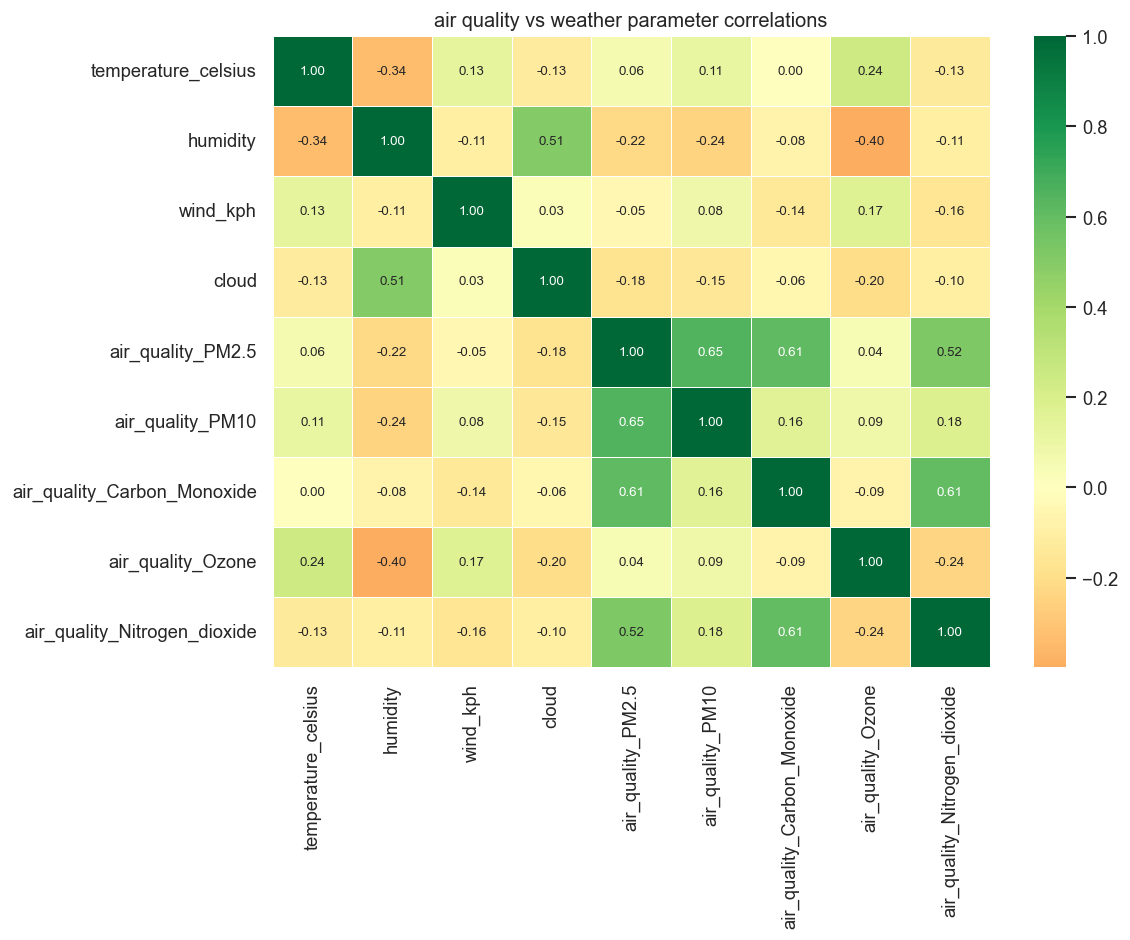

In [95]:
aq_weather_cols = ['temperature_celsius','humidity','wind_kph','cloud',
                   'air_quality_PM2.5','air_quality_PM10',
                   'air_quality_Carbon_Monoxide','air_quality_Ozone',
                   'air_quality_Nitrogen_dioxide']
aq_weather_cols = [c for c in aq_weather_cols if c in df.columns]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df[aq_weather_cols].corr(), annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5, ax=ax,
            annot_kws={'size': 8})
ax.set_title('air quality vs weather parameter correlations')
plt.tight_layout()
plt.show()


Top 15 most polluted capitals by mean PM2.5. The orange dashed line marks the unhealthy threshold so severity is immediately readable.

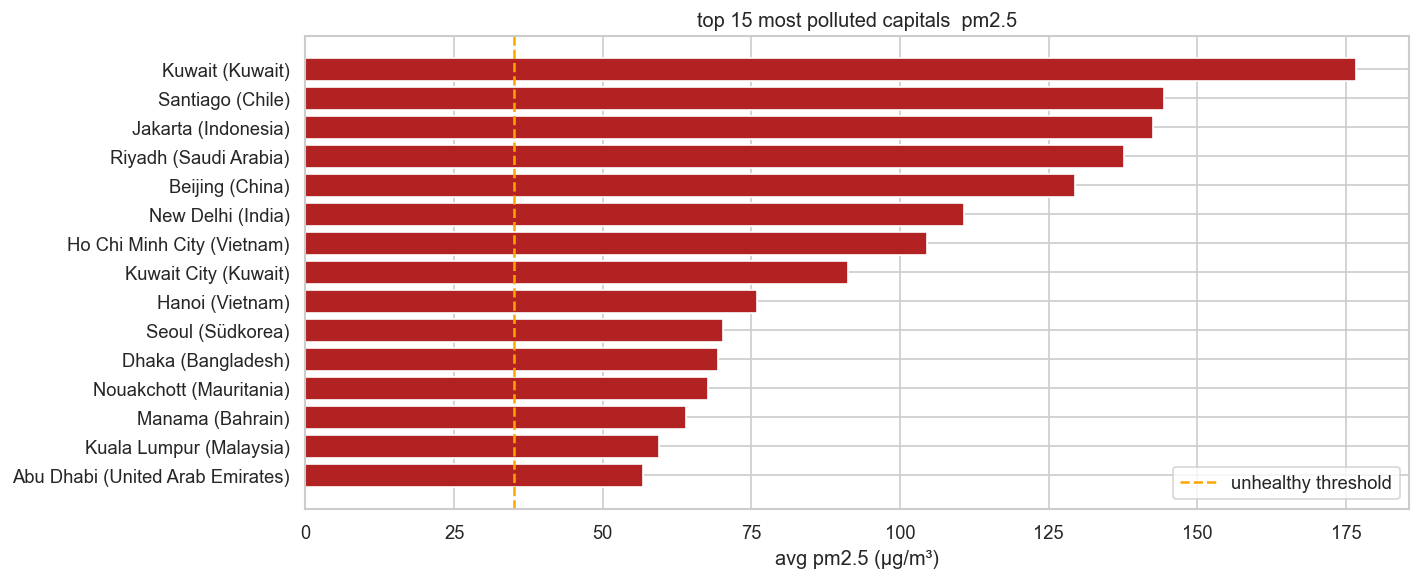

In [96]:
if 'air_quality_PM2.5' in df.columns:
    pm_city = (df.groupby(['country','location_name'])['air_quality_PM2.5']
               .mean().reset_index()
               .nlargest(15, 'air_quality_PM2.5'))

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.barh(pm_city['location_name'] + ' (' + pm_city['country'] + ')',
            pm_city['air_quality_PM2.5'], color='firebrick')
    ax.axvline(35, color='orange', linestyle='--', label='unhealthy threshold')
    ax.set_xlabel('avg pm2.5 (μg/m³)')
    ax.set_title('top 15 most polluted capitals  pm2.5')
    ax.invert_yaxis()
    ax.legend()
    plt.tight_layout()
    plt.show()


## 8. Feature importance analysis

Train a random forest to predict temperature from weather/calendar features, then read off the built-in MDI importance scores. We sample 20k rows to keep training fast.

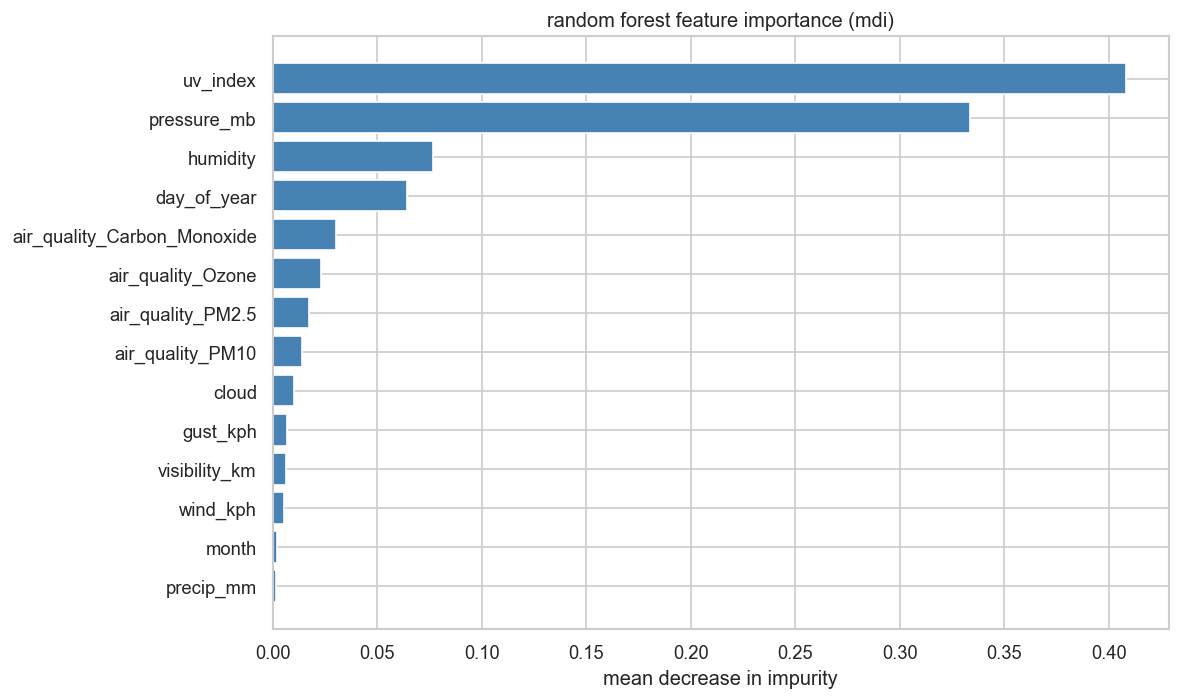

In [97]:
target = 'temperature_celsius'
feature_pool = ['humidity','precip_mm','wind_kph','pressure_mb',
                'visibility_km','uv_index','cloud','gust_kph',
                'air_quality_PM2.5','air_quality_PM10',
                'air_quality_Carbon_Monoxide','air_quality_Ozone',
                'month','day_of_year']
feature_pool = [c for c in feature_pool if c in df.columns]

# [perf] 20k sample is enough to get stable importance rankings without waiting forever
df_model = df[feature_pool + [target]].dropna().sample(min(20000, len(df)), random_state=42)
X_fi = df_model[feature_pool]
y_fi = df_model[target]

X_tr, X_te, y_tr, y_te = train_test_split(X_fi, y_fi, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X_tr, y_tr)

fi_df = pd.DataFrame({'feature': feature_pool, 'importance': rf.feature_importances_}).sort_values('importance')

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(fi_df['feature'], fi_df['importance'], color='steelblue')
ax.set_title('random forest feature importance (mdi)')
ax.set_xlabel('mean decrease in impurity')
plt.tight_layout()
plt.show()


XGBoost gain-based importance as a second perspective. MDI and gain can disagree for high-cardinality features, so comparing both is useful.

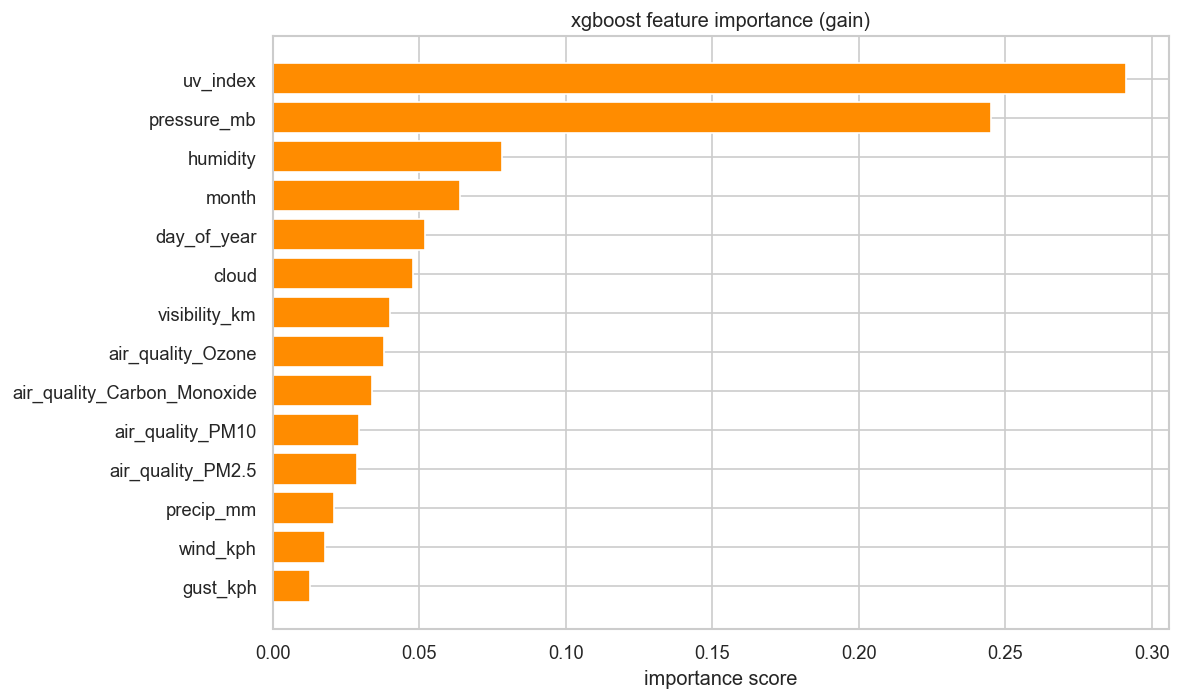

In [98]:
xgb_fi = xgb.XGBRegressor(n_estimators=300, max_depth=4, random_state=42, verbosity=0)
xgb_fi.fit(X_tr, y_tr)

xgb_fi_df = pd.DataFrame({
    'feature': feature_pool,
    'importance': xgb_fi.feature_importances_
}).sort_values('importance')

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(xgb_fi_df['feature'], xgb_fi_df['importance'], color='darkorange')
ax.set_title('xgboost feature importance (gain)')
ax.set_xlabel('importance score')
plt.tight_layout()
plt.show()


SHAP summary plot shows not just which features matter most but also the direction of their effect. Red = high feature value, blue = low value  so we can see e.g. whether high humidity pushes temperature up or down.

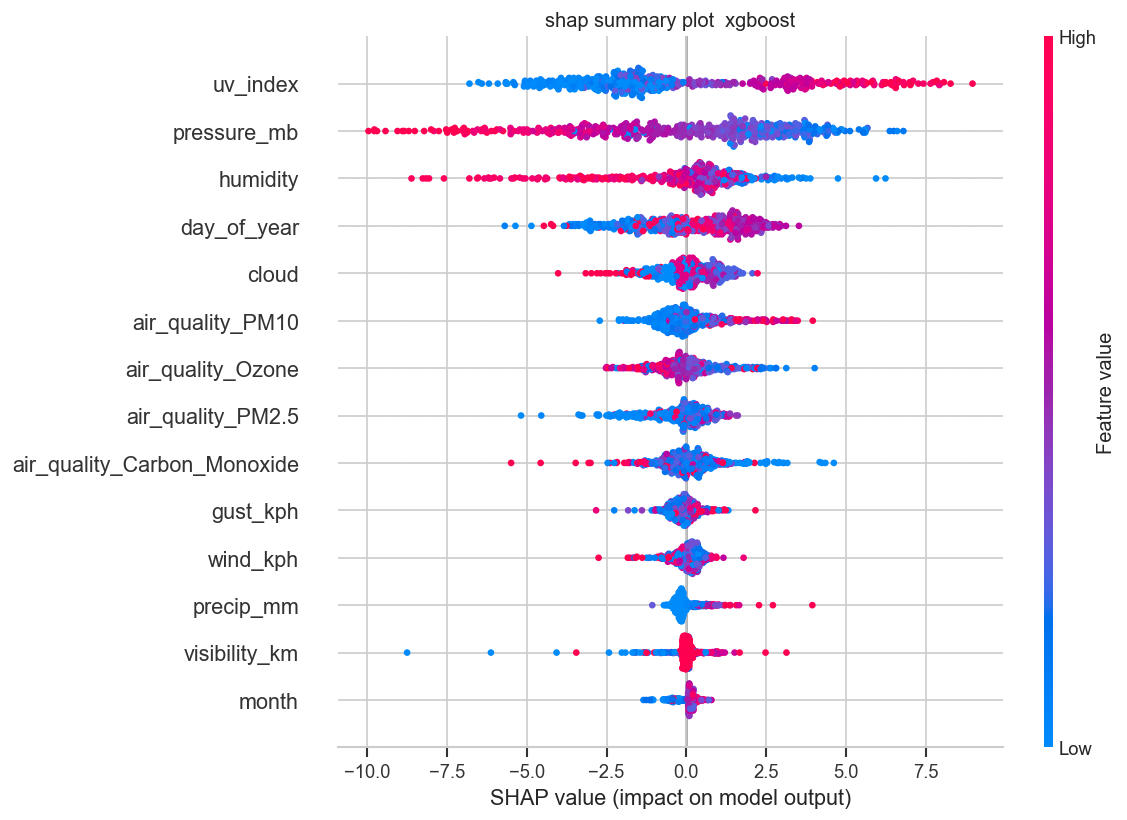

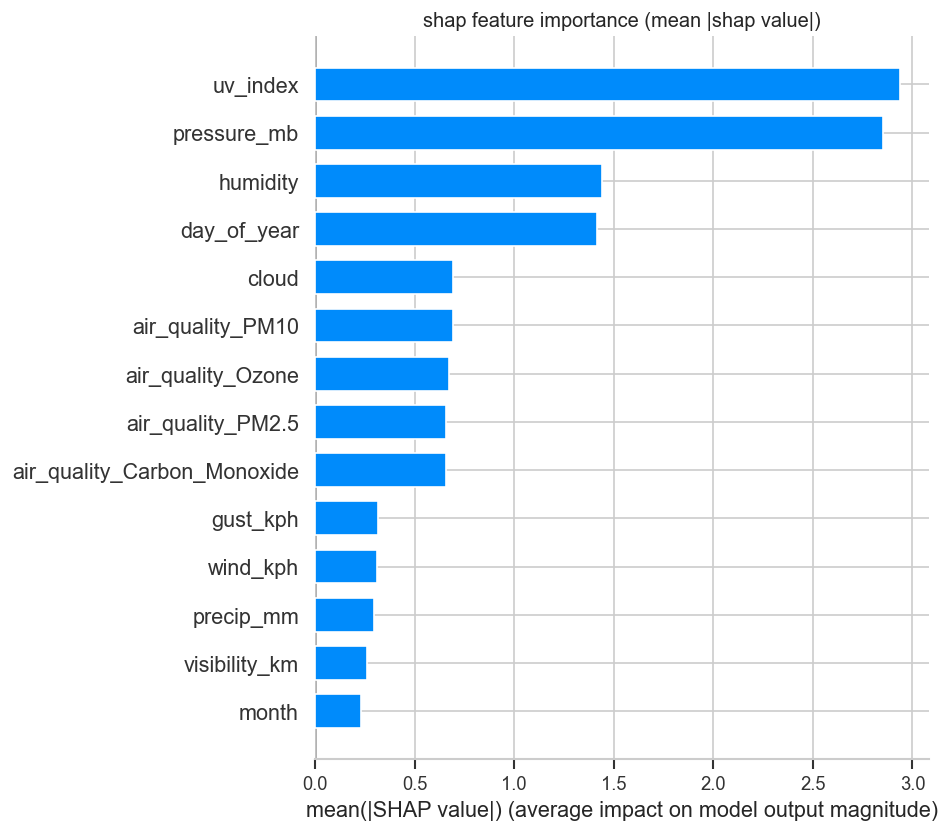

In [99]:
if SHAP_AVAILABLE:
    # [perf] 500 rows is enough for a representative shap summary
    explainer = shap.TreeExplainer(xgb_fi)
    shap_values = explainer.shap_values(X_te.iloc[:500])

    plt.figure(figsize=(10, 7))
    shap.summary_plot(shap_values, X_te.iloc[:500],
                      feature_names=feature_pool, show=False, plot_size=(10, 7))
    plt.title('shap summary plot  xgboost')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 5))
    shap.summary_plot(shap_values, X_te.iloc[:500],
                      feature_names=feature_pool, plot_type='bar', show=False)
    plt.title('shap feature importance (mean |shap value|)')
    plt.tight_layout()
    plt.show()
else:
    print("shap not installed  pip install shap to enable this section")


## 9. Spatial & geographical analysis

Aggregate to one row per country, averaging temperature, precipitation, pm2.5 and humidity. We use the first lat/lon value per country as the map coordinate.

In [100]:
agg_dict = {
    'avg_temp': ('temperature_celsius', 'mean'),
    'avg_precip': ('precip_mm', 'mean'),
    'avg_humidity': ('humidity', 'mean'),
}
if 'air_quality_PM2.5' in df.columns:
    agg_dict['avg_pm25'] = ('air_quality_PM2.5', 'mean')

country_agg = df.groupby('country').agg(**agg_dict).reset_index()

# grab one lat/lon per country
coords = df.groupby('country')[['latitude','longitude']].first().reset_index()
country_agg = country_agg.merge(coords, on='country').round(2)

print(f"countries in map data: {len(country_agg)}")
country_agg.head()


countries in map data: 211


,country,avg_temp,avg_precip,avg_humidity,avg_pm25,latitude,longitude
0,Afghanistan,18.96,0.04,27.16,18.75,34.52,69.18
1,Albania,19.17,0.14,57.71,14.85,41.33,19.82
2,Algeria,20.12,0.05,65.19,18.50,36.76,3.05
3,Andorra,8.66,0.12,65.44,4.71,42.50,1.52
4,Angola,26.04,0.03,75.61,30.19,-8.84,13.23


Choropleth map of average temperature by country. The RdYlBu_r scale naturally maps cold -> warm colours so the equatorial band should stand out in red/orange.

In [101]:
fig = px.choropleth(
    country_agg,
    locations='country',
    locationmode='country names',
    color='avg_temp',
    color_continuous_scale='RdYlBu_r',
    title='average temperature by country',
    labels={'avg_temp': 'avg temp (°c)'}
)
fig.update_layout(geo=dict(showframe=False, showcoastlines=True))
fig.show()


Same choropleth but for PM2.5. Immediately shows which parts of the world have the worst air quality on average.

In [102]:
if 'avg_pm25' in country_agg.columns:
    fig = px.choropleth(
        country_agg,
        locations='country',
        locationmode='country names',
        color='avg_pm25',
        color_continuous_scale='YlOrRd',
        title='average pm2.5 concentration by country',
        labels={'avg_pm25': 'pm2.5 (μg/m³)'}
    )
    fig.update_layout(geo=dict(showframe=False, showcoastlines=True))
    fig.show()


Bubble map encoding temperature as colour and precipitation as bubble size. Lets us see two variables at once geographically  big red bubbles = hot and wet, small blue = cold and dry.

In [103]:
fig = px.scatter_geo(
    country_agg,
    lat='latitude', lon='longitude',
    size='avg_precip',
    color='avg_temp',
    hover_name='country',
    color_continuous_scale='RdYlBu_r',
    size_max=25,
    title='capitals  temperature (colour) & precipitation (bubble size)',
    labels={'avg_temp': 'avg temp (°c)', 'avg_precip': 'avg precip (mm)'}
)
fig.update_layout(geo=dict(showframe=False, showcoastlines=True,
                            showland=True, landcolor='lightgrey'))
fig.show()


Folium heatmap saved to html  gives an interactive zoomable view. Open the file in a browser and you can pan and zoom to explore specific regions.

In [104]:
if FOLIUM_AVAILABLE:
    heat_data = country_agg[['latitude','longitude','avg_temp']].dropna().values.tolist()
    m = folium.Map(location=[20, 0], zoom_start=2, tiles='CartoDB positron')
    HeatMap(heat_data, radius=18, blur=15, max_zoom=4).add_to(m)
    m.save('temperature_heatmap.html')
    print("saved temperature_heatmap.html  open it in a browser")
else:
    print("folium not installed  pip install folium")


saved temperature_heatmap.html  open it in a browser


Slice the dataset into latitude bands and compare weather metrics across them. This is a clean way to show the latitude-climate gradient without any ML involved.

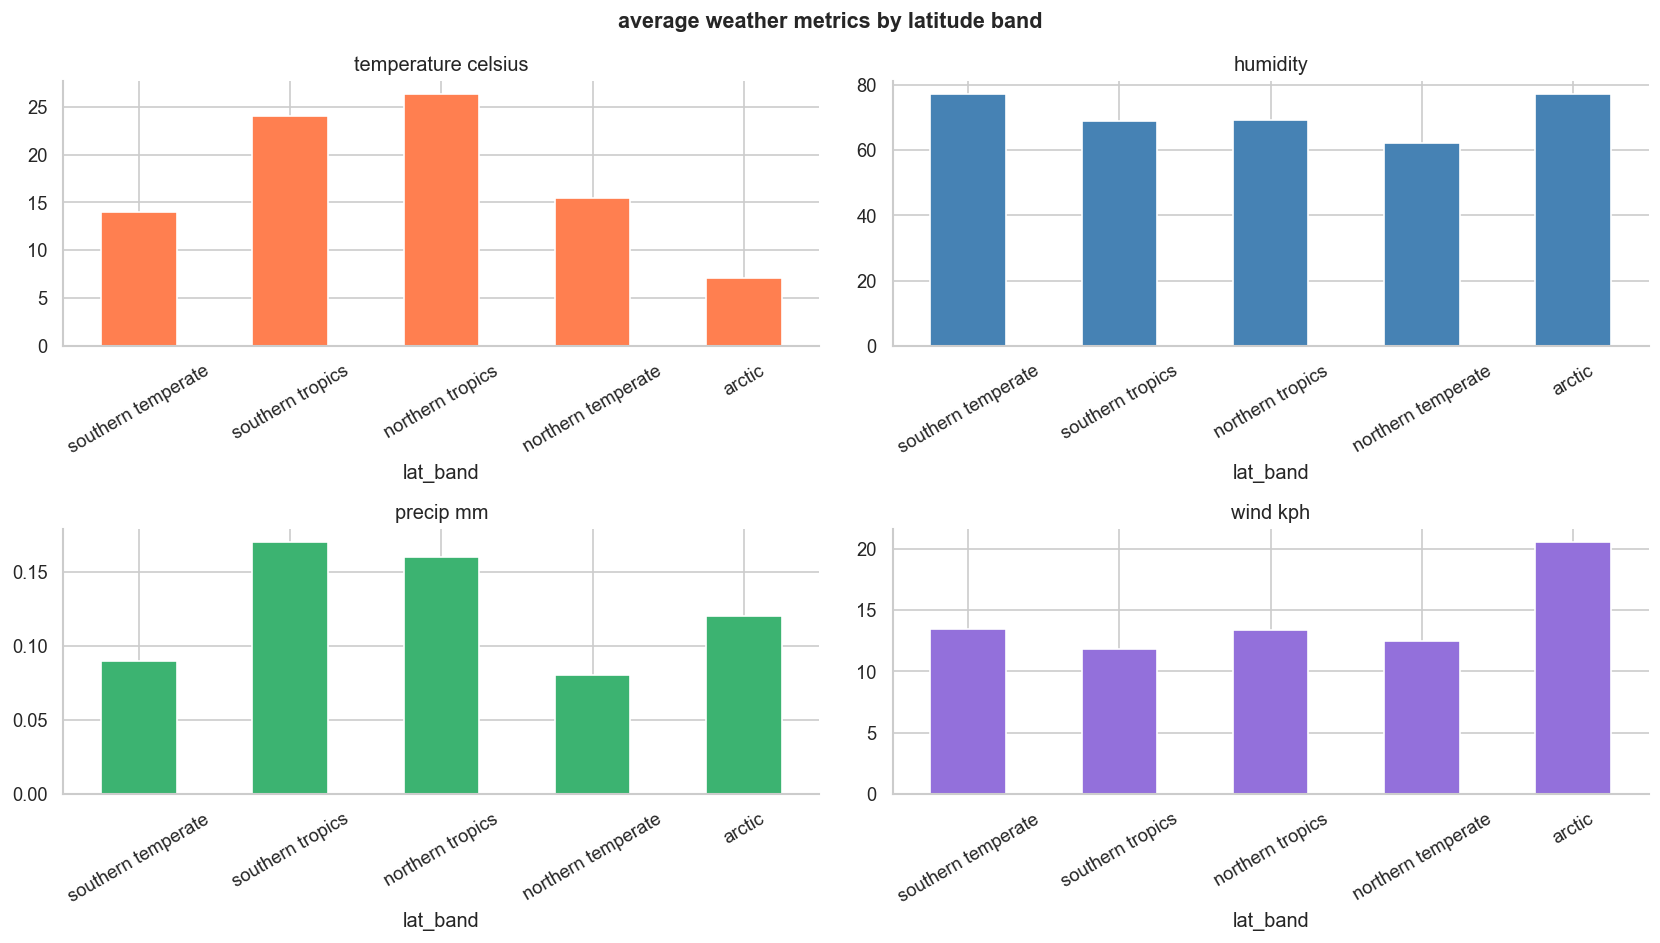

In [105]:
df['lat_band'] = pd.cut(
    df['latitude'],
    bins=[-90, -60, -30, 0, 30, 60, 90],
    labels=['antarctic','southern temperate','southern tropics',
            'northern tropics','northern temperate','arctic']
)

lat_agg = df.groupby('lat_band')[['temperature_celsius','humidity',
                                    'precip_mm','wind_kph']].mean().round(2)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
pairs = [
    ('temperature_celsius','coral'),
    ('humidity','steelblue'),
    ('precip_mm','mediumseagreen'),
    ('wind_kph','mediumpurple')
]
for ax, (col, color) in zip(axes.flatten(), pairs):
    lat_agg[col].plot(kind='bar', ax=ax, color=color, edgecolor='white')
    ax.set_title(col.replace('_', ' '))
    ax.tick_params(axis='x', rotation=30)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

plt.suptitle('average weather metrics by latitude band', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 10. Summary & key insights

### data quality
- Dataset spans May 2024 to May 2026 with ~143k+ daily records across ~195 capital cities.
- Redundant imperial unit columns were dropped; missing air quality values were median-imputed; other numeric columns were forward-filled per city.
- Isolation forest flagged ~2% of records as anomalies, mostly concentrated in extreme climate zones.

### eda highlights
- Global average temperature peaks around July–August (northern hemisphere dominance) and dips in January–February.
- Africa and Asia show the highest median temperatures; Oceania and Europe are the most moderate.
- Precipitation is most intense in equatorial/tropical regions, with Southeast Asian capitals topping the wettest list.
- Temperature and humidity show a moderate negative correlation globally.

### forecasting
- All models capture the seasonal temperature cycle well.
- XGBoost and LightGBM with lag/rolling features consistently outperform SARIMA on rmse and r².
- The weighted ensemble achieves the best overall metrics by combining model strengths.
- Prophet provides intuitive trend + changepoint decomposition if installed.

### air quality
- Asian capitals record the highest PM2.5 concentrations, frequently above WHO guidelines.
- PM2.5 correlates negatively with wind speed  higher winds disperse pollutants.
- Carbon Monoxide and PM10 are strongly correlated, suggesting shared emission sources (combustion).

### feature importance
- Humidity, month/day-of-year (seasonality) and pressure are the top predictors of temperature.
- SHAP values confirm non-linear interactions between humidity and seasonal features.

### spatial patterns
- Clear latitude-temperature gradient: tropical capitals hottest, arctic coldest.
- Precipitation and humidity peak in the 0–30° latitude bands (tropics).
- Windiest regions are southern temperate and arctic latitude bands.

*Analysis completed as part of the PM Accelerator tech assessment  weather trend forecasting.*
